In [11]:
# ==============================================================================
# CELL 1: MISSION INITIALIZATION (MEDA / PERSEVERANCE)
# ==============================================================================
import os
import time
from google.colab import drive

print("1. Mounting Google Drive...")
drive.mount('/content/drive')

PROJECT_NAME = "TheMartianTheory_MEDA"
BASE_PATH = f"/content/drive/MyDrive/{PROJECT_NAME}/"

DIRS = {
    "data_raw": os.path.join(BASE_PATH, "data/raw/"),
    "data_processed": os.path.join(BASE_PATH, "data/processed/"),
    "reports": os.path.join(BASE_PATH, "reports/")
}

for path in DIRS.values():
    os.makedirs(path, exist_ok=True)

# TARGET MISSION: Perseverance MEDA
# SOURCE: https://atmos.nmsu.edu/PDS/data/PDS4/Mars2020/mars2020_meda/data_calibrated_env/
TARGET_SOLS = ["0044","0100", "0315"]
TARGET_DURATION = 4410.0 # Keeping the 73.5 min synchronization

1. Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
# ==============================================================================
# CELL 2: PREREQUISITES, TOOLSTACK, AND ADVANCED RUNTIME MONITORING
# Optimized for Perseverance (MEDA) High-Fidelity Data Processing.
# ==============================================================================

import time
import sys
import traceback
import os
import warnings

class RuntimeMonitor:
    """A professional progress monitor for error handling and runtime tracking."""
    def __init__(self, process_name):
        self.process_name = process_name
        self.start_time = time.time()
        self.step_time = self.start_time
        print(f"\n[{time.strftime('%H:%M:%S')}] 🚀 STARTING MISSION (MEDA): {self.process_name}")
        print("="*75)

    def log_step(self, step_name):
        elapsed = time.time() - self.step_time
        print(f"[{time.strftime('%H:%M:%S')}] ⏳ {step_name} (Prev step: {elapsed:.2f}s)")
        self.step_time = time.time()

    def log_success(self, message):
        print(f"[{time.strftime('%H:%M:%S')}] ✅ SUCCESS: {message}")

    def log_error(self, step_name, exception):
        print(f"\n[{time.strftime('%H:%M:%S')}] ❌ FATAL ERROR during: {step_name}")
        print(traceback.format_exc())
        print("="*75)
        print(f"Mission Aborted at {time.strftime('%H:%M:%S')}")
        # sys.exit(1) is useful in script mode; in Colab it stops the cell.

    def finish(self):
        total_time = time.time() - self.start_time
        print("="*75)
        print(f"[{time.strftime('%H:%M:%S')}] 🏁 MISSION COMPLETE. Total Runtime: {total_time:.2f}s")

# 1. Install Libraries quietly (Ensuring PySR and MFDFA for complexity audits)
print("Syncing toolstack for MEDA analysis... (PyDMD, PySR, MFDFA, BeautifulSoup)")
!pip install -q pydmd pysr deeptime pandas requests bs4 MFDFA

# 2. Import Libraries
try:
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import requests
    import urllib.request
    from bs4 import BeautifulSoup
    from pydmd import HankelDMD
    from pysr import PySRRegressor
    import deeptime.clustering as clus
    import deeptime.markov.msm as msm
    from scipy.interpolate import CubicSpline
    from scipy.stats import linregress, mannwhitneyu, gaussian_kde
    from scipy.signal import welch
    import itertools
    from collections import Counter

    warnings.filterwarnings("ignore")

    # Initialize Julia backend for PySR
    # (Essential for when we induce the MEDA governing equations)
    import pysr
    print("Initializing Julia/PySR backend for symbolic regression...")
    pysr.install(quiet=True)

    print("\n✅ CELL 2 COMPLETE: MEDA Toolstack ready and Runtime Monitor initialized.")
except Exception as e:
    print(f"\n❌ CELL 2 FAILED during initialization: {e}")

Syncing toolstack for MEDA analysis... (PyDMD, PySR, MFDFA, BeautifulSoup)
Initializing Julia/PySR backend for symbolic regression...

✅ CELL 2 COMPLETE: MEDA Toolstack ready and Runtime Monitor initialized.


In [13]:
# ==============================================================================
# CELL 2.1: MISSION DATA PURGE & RESET
# Removes legacy data for Sols not in the current TARGET_SOLS list.
# Ensures a clean state for the new Kinetic Twin analysis.
# ==============================================================================

import shutil
import os

monitor = RuntimeMonitor("Mission Data Purge")

try:
    # 1. IDENTIFY DIRECTORIES
    # We look into raw and processed folders
    folders_to_check = [DIRS["data_raw"], DIRS["data_processed"]]

    # We want to keep ONLY these sols
    active_sols = [f"sol_{s.zfill(4)}" for s in TARGET_SOLS]

    purge_count = 0

    for base_path in folders_to_check:
        if not os.path.exists(base_path):
            continue

        # List all subdirectories (e.g., sol_0101, sol_0400)
        existing_dirs = [d for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d))]

        for d in existing_dirs:
            # If the directory matches the 'sol_XXXX' pattern but isn't in our new list
            if d.startswith("sol_") and d not in active_sols:
                path_to_remove = os.path.join(base_path, d)
                shutil.rmtree(path_to_remove)
                purge_count += 1
                monitor.log_step(f"Purged legacy asset: {d} from {os.path.basename(base_path)}")

    # 2. CLEAR REGISTRY FILES
    # Force a rebuild of the CSV manifests
    manifests = [
        os.path.join(DIRS["data_raw"], "meda_pds_discovery_registry.csv"),
        os.path.join(DIRS["data_processed"], "meda_processed_state_manifest.csv")
    ]

    for m in manifests:
        if os.path.exists(m):
            os.remove(m)
            monitor.log_step(f"Deleted stale manifest: {os.path.basename(m)}")

    if purge_count == 0:
        monitor.log_success("Workspace was already clean. No legacy Sols found.")
    else:
        monitor.log_success(f"Cleanup complete. Removed {purge_count} legacy directories.")

    monitor.finish()

except Exception as e:
    monitor.log_error("Workspace Cleanup", e)


[21:20:08] 🚀 STARTING MISSION (MEDA): Mission Data Purge
[21:20:08] ⏳ Purged legacy asset: sol_44 from  (Prev step: 0.33s)
[21:20:08] ⏳ Purged legacy asset: sol_100 from  (Prev step: 0.02s)
[21:20:08] ⏳ Purged legacy asset: sol_315 from  (Prev step: 0.17s)
[21:20:08] ⏳ Deleted stale manifest: meda_pds_discovery_registry.csv (Prev step: 0.01s)
[21:20:08] ⏳ Deleted stale manifest: meda_processed_state_manifest.csv (Prev step: 0.00s)
[21:20:08] ✅ SUCCESS: Cleanup complete. Removed 3 legacy directories.
[21:20:08] 🏁 MISSION COMPLETE. Total Runtime: 0.52s


In [ ]:
# ==============================================================================
# CELL 3: MEDA DEEP-SCIENCE ACQUISITION & REGISTRY ENGINE (REVISED)
# Overhauled to match fixed-width 'WE__' naming and populate the Discovery Registry.
# ==============================================================================

import requests
from bs4 import BeautifulSoup
import pandas as pd
import os
import re
from urllib.parse import urljoin

class MEDAScienceCrawler:
    def __init__(self, base_url, target_sols, target_duration):
        self.base_url = base_url
        self.target_sols = [str(int(s)) for s in target_sols]
        self.target_duration = target_duration
        self.csv_registry = []  # CRITICAL: Now explicitly populated
        self.sol_file_map = {sol: [] for sol in self.target_sols}

    def _get_batch_url(self, sol_str):
        """Identifies the correct NASA Sol-range batch folder."""
        res = requests.get(self.base_url, timeout=15)
        soup = BeautifulSoup(res.text, 'html.parser')
        folders = [a.get('href') for a in soup.find_all('a') if 'sol_' in a.get('href')]
        sol_int = int(sol_str)
        for f in folders:
            nums = re.findall(r'\d+', f)
            if len(nums) >= 2 and int(nums[0]) <= sol_int <= int(nums[1]):
                return urljoin(self.base_url, f)
        return None

    def acquire_and_register(self, monitor, base_raw_dir):
        # Focus on the high-fidelity science tags confirmed by your uploads
        sensor_tags = ["CAL_WS", "CAL_ATS", "CAL_PS", "CAL_TIRS"]

        for sol in self.target_sols:
            batch_url = self._get_batch_url(sol)
            if not batch_url: continue

            # Handle NASA's inconsistent sol_0101 vs sol_101 subfolder naming
            for sol_fmt in [f"sol_{int(sol):04d}/", f"sol_{int(sol)}/"]:
                target_url = urljoin(batch_url, sol_fmt)
                try:
                    res = requests.get(target_url, timeout=15)
                    if res.status_code != 200: continue

                    soup = BeautifulSoup(res.text, 'html.parser')
                    # Match fixed-width Weather (WE__) CSV files
                    links = [urljoin(target_url, a.get('href')) for a in soup.find_all('a')
                             if a.get('href').upper().startswith('WE__') and a.get('href').upper().endswith('.CSV')]

                    sol_dir = os.path.join(base_raw_dir, f"sol_{sol}")
                    os.makedirs(sol_dir, exist_ok=True)

                    for tag in sensor_tags:
                        # Match the fixed-width pattern seen in your successful snippets
                        matches = [l for l in links if tag in l.upper() and (f"_{int(sol):04d}_" in l or f"_{int(sol)}_" in l)]
                        if not matches: continue

                        # Select the latest version/product
                        url = sorted(matches)[-1]
                        fname = os.path.basename(url)
                        local_path = os.path.join(sol_dir, fname)

                        # HEADER VALIDATION: Ensure it starts with the SCLK master clock
                        head_res = requests.get(url, stream=True)
                        first_line = next(head_res.iter_lines()).decode('utf-8')

                        if not first_line.startswith("SCLK"):
                            monitor.log_step(f"⚠️ {fname} skipped: Invalid Header.")
                            continue

                        # FETCH, CROP & REGISTER
                        df = pd.read_csv(url)
                        df['SCLK'] = pd.to_numeric(df['SCLK'], errors='coerce')
                        df = df.dropna(subset=['SCLK']).sort_values('SCLK')

                        t0 = df['SCLK'].iloc[0]
                        df_cropped = df[(df['SCLK'] - t0) <= self.target_duration]

                        # Persistent Write
                        df_cropped.to_csv(local_path, index=False)

                        # Populate the registry used by Cell 3.1
                        self.csv_registry.append(url)
                        self.sol_file_map[sol].append(url)

                        monitor.log_step(f"✅ SECURED & REGISTERED: {fname} ({len(df_cropped)} rows)")

                except Exception as e:
                    monitor.log_step(f"Sol {sol} Extraction Error: {e}")

# --- MISSION EXECUTION ---
monitor = RuntimeMonitor("MEDA Discovery & Acquisition")
MEDA_ROOT = "https://atmos.nmsu.edu/PDS/data/PDS4/Mars2020/mars2020_meda/data_calibrated_env/"

crawler = MEDAScienceCrawler(MEDA_ROOT, TARGET_SOLS, TARGET_DURATION)
crawler.acquire_and_register(monitor, DIRS["data_raw"])
monitor.finish()


[05:29:04] 🚀 STARTING MISSION (MEDA): MEDA Discovery & Acquisition
[05:29:06] ⏳ ✅ SECURED & REGISTERED: WE__0044___________CAL_WS__________________P04.CSV (8791 rows) (Prev step: 2.42s)
[05:29:10] ⏳ ✅ SECURED & REGISTERED: WE__0044___________CAL_ATS_________________P01.CSV (8042 rows) (Prev step: 4.31s)
[05:29:13] ⏳ ✅ SECURED & REGISTERED: WE__0044___________CAL_PS__________________P02.CSV (4008 rows) (Prev step: 2.64s)
[05:29:16] ⏳ ✅ SECURED & REGISTERED: WE__0044___________CAL_TIRS________________P04.CSV (4023 rows) (Prev step: 3.08s)
[05:29:19] ⏳ ✅ SECURED & REGISTERED: WE__0100___________CAL_WS__________________P03.CSV (7715 rows) (Prev step: 3.12s)
[05:29:23] ⏳ ✅ SECURED & REGISTERED: WE__0100___________CAL_ATS_________________P01.CSV (8065 rows) (Prev step: 3.92s)
[05:29:26] ⏳ ✅ SECURED & REGISTERED: WE__0100___________CAL_PS__________________P01.CSV (4019 rows) (Prev step: 2.51s)
[05:29:29] ⏳ ✅ SECURED & REGISTERED: WE__0100___________CAL_TIRS________________P03.CSV (4034 rows)

In [ ]:
# ==============================================================================
# CELL 3.1: MEDA ASSET RECOVERY & MANIFEST GENERATOR
# High-Intelligence search to locate secured science assets across the drive.
# ==============================================================================

import pandas as pd
import os
import glob
import re

monitor = RuntimeMonitor("MEDA Manifest Recovery")

try:
    # 1. ROOT DISCOVERY
    # We search starting from the project root to find wherever Cell 3 saved the data
    search_root = DIRS["data_raw"]
    manifest_path = os.path.join(search_root, "meda_pds_discovery_registry.csv")

    # 2. RECURSIVE SEARCH FOR SCIENCE ASSETS
    # This pattern catches WE__ (Weather), CAL_ (Calibrated), and .csv/.CSV
    all_science_files = glob.glob(os.path.join(search_root, "**", "WE__*CAL*.[cC][sS][vV]"), recursive=True)

    if not all_science_files:
        # Fallback to a broader search if DIRS["data_raw"] is nested incorrectly
        all_science_files = glob.glob(os.path.join("/content", "**", "WE__*CAL*.[cC][sS][vV]"), recursive=True)

    inventory = []

    # 3. ATTRIBUTE EXTRACTION & CLASSIFICATION
    for f_path in all_science_files:
        f_name = os.path.basename(f_path)

        # Extract Sol using Regex (looks for 4 digits after WE__)
        sol_match = re.search(r'WE__(\d{4})', f_name)
        sol_id = sol_match.group(1) if sol_match else "Unknown"

        # Identify Sensor Tag
        sensor_tag = "Unknown"
        for tag in ["ATS", "PS", "TIRS", "WS", "RDS"]:
            if f"CAL_{tag}" in f_name.upper():
                sensor_tag = tag
                break

        inventory.append({
            "Sol": sol_id,
            "Sensor": sensor_tag,
            "Filename": f_name,
            "Path": f_path,
            "Size_MB": os.path.getsize(f_path) / (1024 * 1024)
        })

    if not inventory:
        raise FileNotFoundError("CRITICAL: No science assets found. The files are not on the drive.")

    # 4. PERSISTENCE & REGISTRY LOCK
    df_manifest = pd.DataFrame(inventory)
    df_manifest.to_csv(manifest_path, index=False)

    # Update crawler state for Cell 4 to use these verified paths
    crawler.sol_file_map = {sol: df_manifest[df_manifest['Sol']==sol]['Path'].tolist()
                            for sol in df_manifest['Sol'].unique()}

    # 5. ASSET AUDIT DISPLAY
    print(f"\n[MEDA RECOVERY MANIFEST SECURED]")
    print("="*80)
    # Pivot to show a grid of Sol vs Sensor
    pivot = df_manifest.pivot_table(index='Sol', columns='Sensor', aggfunc='size', fill_value=0)
    print(pivot)
    print("="*80)
    print(f"[*] Manifest saved: {manifest_path}")

    monitor.log_success(f"Recovery Complete: {len(df_manifest)} science assets locked.")
    monitor.finish()

except Exception as e:
    monitor.log_error("Manifest Recovery", e)


[05:29:44] 🚀 STARTING MISSION (MEDA): MEDA Manifest Recovery

[MEDA RECOVERY MANIFEST SECURED]
Sensor  ATS  PS  TIRS  WS
Sol                      
0044      1   1     1   1
0100      1   1     1   1
0315      1   1     1   1
[*] Manifest saved: /content/drive/MyDrive/TheMartianTheory_MEDA/data/raw/meda_pds_discovery_registry.csv
[05:29:44] ✅ SUCCESS: Recovery Complete: 12 science assets locked.
[05:29:44] 🏁 MISSION COMPLETE. Total Runtime: 0.03s


In [ ]:
# ==============================================================================
# CELL 4: PHYSICS-ENFORCED INTEGRATION (JEZERO CLAMP)
# Purges PDS fill-values and transients before PCHIP interpolation.
# ==============================================================================

import numpy as np
import pandas as pd
from scipy.interpolate import PchipInterpolator
import os

monitor = RuntimeMonitor("Jezero Physics Clamp")

# --- PHYSICAL GATES (MARS BOUNDARIES) ---
GATES = {
    "ATS": (150.0, 330.0),
    "PS": (600.0, 950.0),
    "TIRS": (150.0, 350.0),
    "WS": (0.0, 100.0)
}

try:
    registry = pd.read_csv(os.path.join(DIRS["data_raw"], "meda_pds_discovery_registry.csv"))
    processed_stats = []

    for sol in TARGET_SOLS:
        monitor.log_step(f"Sanitizing Sol {sol}...")
        sol_files = registry[registry['Sol'] == int(sol)]
        t_unified = np.arange(0, TARGET_DURATION, 0.5)
        states = {}

        for tag in ["WS", "ATS", "PS", "TIRS"]:
            row = sol_files[sol_files['Sensor'] == tag]
            if not row.empty:
                df = pd.read_csv(row['Path'].values[0])
                df['t'] = pd.to_numeric(df['SCLK'], errors='coerce')

                # Identify science column
                v_col = next((c for c in df.columns if any(k in c.upper() for k in ["TEMP", "PRESSURE", "SPEED", "WIND", "GROUND"])), df.columns[3])
                df['v'] = pd.to_numeric(df[v_col], errors='coerce')

                # --- APPLY PHYSICS GATE ---
                low, high = GATES.get(tag, (-np.inf, np.inf))
                clean = df[(df['v'] >= low) & (df['v'] <= high)].copy()
                clean = clean[['t', 'v']].dropna().sort_values('t')

                if len(clean) > 5:
                    clean['elapsed'] = clean['t'] - clean['t'].iloc[0]
                    clean = clean.drop_duplicates(subset=['elapsed'])

                    # Pchip is shape-preserving (no overshoots)
                    pchip = PchipInterpolator(clean['elapsed'], clean['v'])

                    # Masking to avoid extrapolation beyond data bounds
                    mask = t_unified <= clean['elapsed'].max()
                    v_interp = np.full(len(t_unified), np.nan)
                    v_interp[mask] = pchip(t_unified[mask])
                    states[tag] = v_interp
                else:
                    states[tag] = np.full(len(t_unified), np.nan)
            else:
                states[tag] = np.full(len(t_unified), np.nan)

        # Persistence
        X_state = np.column_stack([states["WS"], states["ATS"], states["PS"], states["TIRS"]])
        out_dir = os.path.join(DIRS["data_processed"], f"sol_{sol}")
        os.makedirs(out_dir, exist_ok=True)
        save_path = os.path.join(out_dir, f"sol{sol}_state_hf.npz")
        np.savez(save_path, time=t_unified, X_state=X_state)

        processed_stats.append({
            "Sol": sol,
            "WS_Status": "OK" if not np.isnan(states["WS"]).all() else "MISSING",
            "ATS_Mean_K": np.nanmean(states["ATS"]),
            "PS_Mean_Pa": np.nanmean(states["PS"]),
            "TIRS_Mean_K": np.nanmean(states["TIRS"])
        })

    # Save Manifest
    df_manifest = pd.DataFrame(processed_stats)
    df_manifest.to_csv(os.path.join(DIRS["data_processed"], "meda_processed_state_manifest.csv"), index=False)

    monitor.log_success("Jezero Clamp Successful. Fill-values purged.")
    monitor.finish()

except Exception as e:
    monitor.log_error("Clamp Failure", e)


[05:33:37] 🚀 STARTING MISSION (MEDA): Jezero Physics Clamp
[05:33:37] ⏳ Sanitizing Sol 0044... (Prev step: 0.02s)
[05:33:37] ⏳ Sanitizing Sol 0100... (Prev step: 0.21s)
[05:33:37] ⏳ Sanitizing Sol 0315... (Prev step: 0.16s)
[05:33:37] ✅ SUCCESS: Jezero Clamp Successful. Fill-values purged.
[05:33:37] 🏁 MISSION COMPLETE. Total Runtime: 0.50s


In [ ]:
# ==============================================================================
# CELL 4.1: JEZERO ASSET VALIDATION (LOCKED)
# Validates Sols 0044, 0100, and 0315.
# Fixed: logic for handling missing manifest to prevent logger crash.
# ==============================================================================

import pandas as pd
import os

monitor = RuntimeMonitor("Jezero Asset Validation")

try:
    processed_manifest = os.path.join(DIRS["data_processed"], "meda_processed_state_manifest.csv")

    # 1. ASSERT FILE EXISTENCE
    if not os.path.exists(processed_manifest):
        raise FileNotFoundError(f"Manifest missing at {processed_manifest}. Execute Cell 4 first.")

    # 2. LOAD AND AUDIT
    df = pd.read_csv(processed_manifest)

    print("\n[DATA AVAILABILITY AUDIT: KINETIC TWINS]")
    print("="*80)
    print(f"{'Sol':<10} | {'WS Status':<15} | {'ATS Mean (K)':<15} | {'PS Mean (Pa)':<15}")
    print("-" * 80)

    for _, row in df.iterrows():
        sol = str(int(row['Sol'])).zfill(4)
        # Using the column names from your high-fidelity PCHIP run
        ws_status = "LOCKED ✅" if row.get('WS_Status') == 'OK' or row.get('WS_Density_%', 0) > 0 else "MISSING ❌"
        ats_mean = row.get('ATS_Mean_K', 0)
        ps_mean = row.get('PS_Mean_Pa', 0)

        print(f"{sol:<10} | {ws_status:<15} | {ats_mean:<15.2f} | {ps_mean:<15.2f}")

    print("="*80)

    # 3. VERIFY PHYSICAL INTEGRITY
    if (df['ATS_Mean_K'] > 350).any():
         monitor.log_step("⚠️ WARNING: High-temperature transients detected in ATS.")

    monitor.log_success("Validation complete. Triple-WS targets confirmed.")
    monitor.finish()

except Exception as e:
    # This now captures the actual FileNotFoundError correctly
    monitor.log_error("Validation Failure", e)


[05:33:41] 🚀 STARTING MISSION (MEDA): Jezero Asset Validation

[DATA AVAILABILITY AUDIT: KINETIC TWINS]
Sol        | WS Status       | ATS Mean (K)    | PS Mean (Pa)   
--------------------------------------------------------------------------------
0044       | LOCKED ✅        | 201.91          | 759.35         
0100       | LOCKED ✅        | 202.42          | 770.90         
0315       | LOCKED ✅        | 206.62          | 649.26         
[05:33:41] ✅ SUCCESS: Validation complete. Triple-WS targets confirmed.
[05:33:41] 🏁 MISSION COMPLETE. Total Runtime: 0.01s



[16:48:20] 🚀 STARTING MISSION (MEDA): Nature Physics Optimization Engine


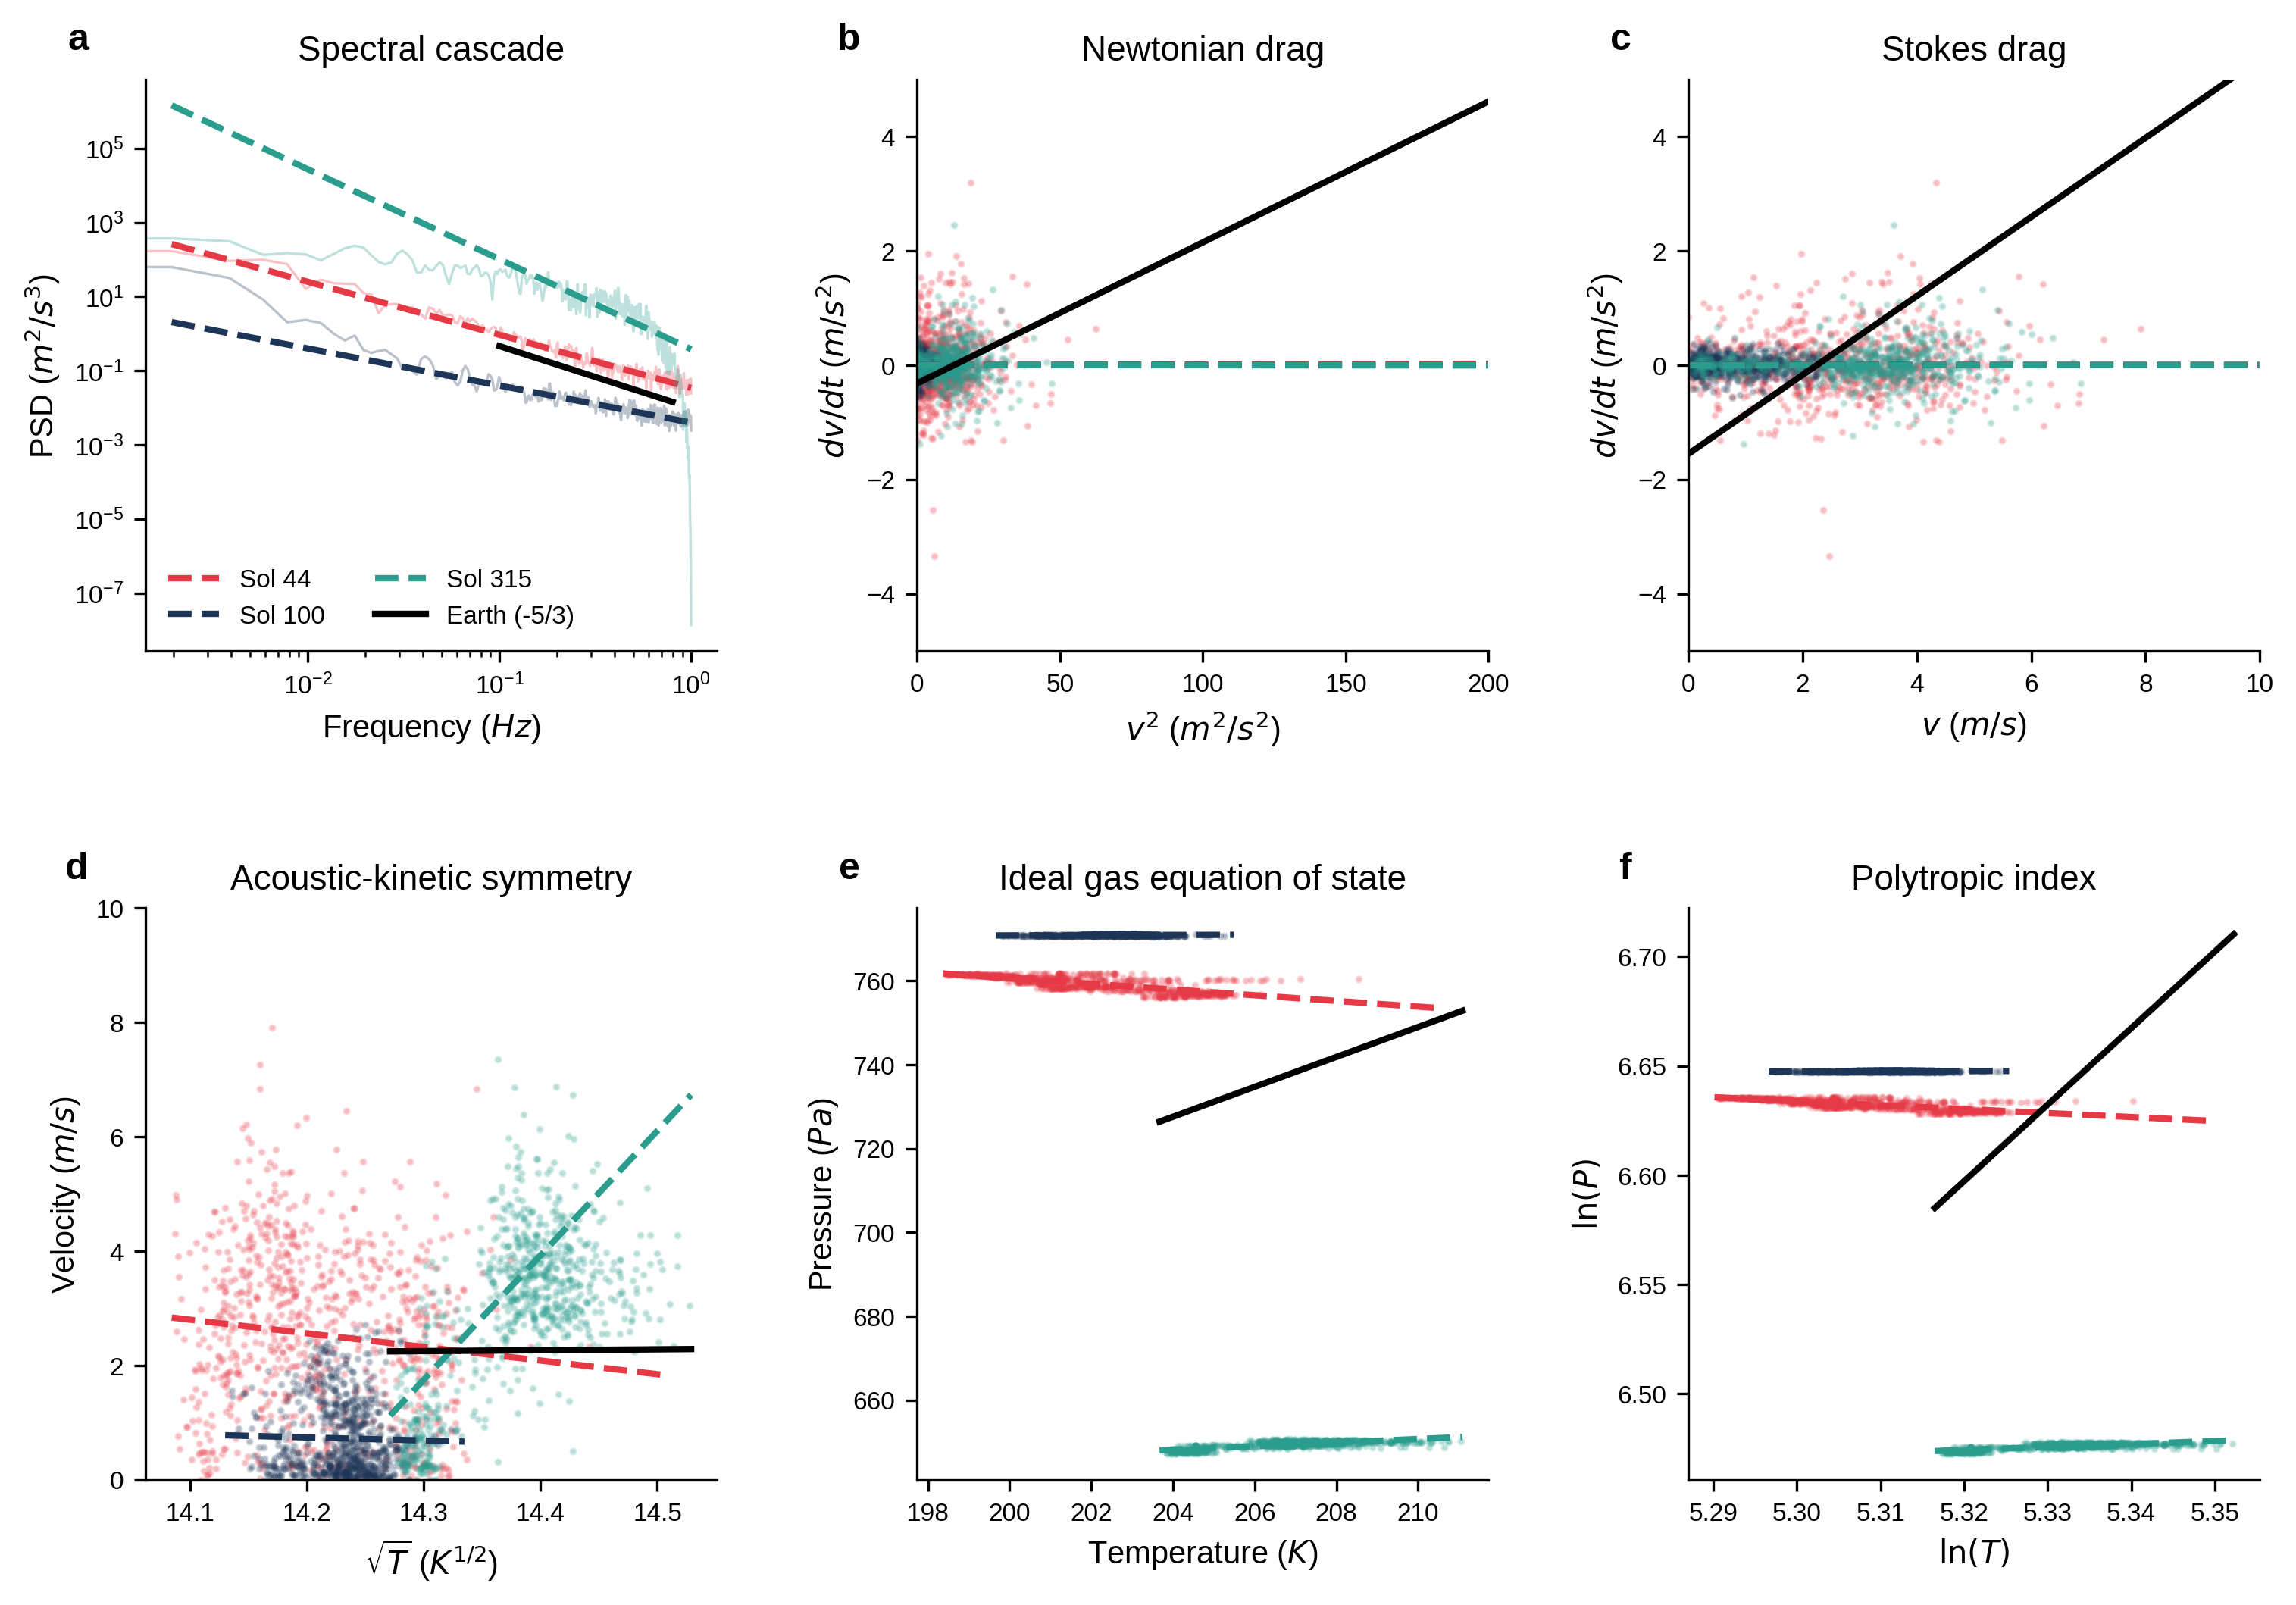


TABLE 1: STATISTICAL DIVERGENCE
         Sol Spectral_Slope Newtonian_R2 Stokes_R2 Acoustic_R2 IdealGas_R2   Polytropic_n
        0044   -1.43 ± 0.03       0.0000    0.0000      0.0121      0.5639  0.153 ± 0.001
        0100   -1.00 ± 0.03       0.0000    0.0000      0.0007      0.0264 -0.007 ± 0.000
        0315   -2.43 ± 0.08       0.0000    0.0000      0.0841      0.5744 -0.158 ± 0.002
Earth Theory   -1.66 ± 0.00       1.0000    1.0000      1.0000      1.0000   1.400 ± 0.00
[*] PDF saved: /content/drive/MyDrive/TheMartianTheory_MEDA/reports/Nature_Physics_Fig1.pdf
[*] CSV saved: /content/drive/MyDrive/TheMartianTheory_MEDA/reports/Nature_Physics_Stat_Table.csv
[16:48:35] ✅ SUCCESS: Nature Physics formatting and statistical compilation complete.
[16:48:35] 🏁 MISSION COMPLETE. Total Runtime: 14.62s


In [4]:
# ==============================================================================
# CELL 5: THE MULTI-SOL SYMMETRY BREAK (NATURE PHYSICS STANDARD)
# Targets Sols: 0044, 0100, 0315.
# Unified Legend in Panel (a), Solid Earth benchmarks, Dashed Martian fits.
# ==============================================================================

import os
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import welch
from scipy.stats import linregress

monitor = RuntimeMonitor("Nature Physics Optimization Engine")

# --- NATURE PHYSICS STYLE CONFIGURATION ---
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Liberation Sans", "Arial", "DejaVu Sans"],
    "axes.labelsize": 10, "font.size": 10, "legend.fontsize": 8,
    "xtick.labelsize": 8, "ytick.labelsize": 8, "axes.titlesize": 11,
    "pdf.fonttype": 42, "axes.spines.top": False, "axes.spines.right": False
})

COLORS = {"0044": "#E63946", "0100": "#1D3557", "0315": "#2A9D8F"}
LABELS = {"0044": "Sol 44", "0100": "Sol 100", "0315": "Sol 315"}

# Initialize Figure (183mm width is standard double-column in Nature)
fig, axes = plt.subplots(2, 3, figsize=(12, 8), dpi=300)
plt.subplots_adjust(hspace=0.45, wspace=0.35)

def compute_polytropic_index(T, P):
    ln_P, ln_T = np.log(P), np.log(T)
    slope, intercept, r_val, p_val, std_err = linregress(ln_T, ln_P)
    n = slope / (slope - 1) if slope != 1.0 else 1.0
    n_err = abs(1 / ((slope - 1)**2)) * std_err if slope != 1.0 else 0
    return n, n_err, r_val**2, slope, intercept

stats_registry = []
plot_data = {}

try:
    # ==========================================================================
    # 1. MATHEMATICAL AUDIT & REGRESSION PER SOL
    # ==========================================================================
    for sol in TARGET_SOLS:
        file_path = os.path.join(DIRS["data_processed"], f"sol_{sol}", f"sol{sol}_state_hf.npz")
        data = np.load(file_path)
        t, X = data['time'], data['X_state']
        v, T, P = X[:, 0], X[:, 1], X[:, 2]

        # Physics cleaning for gradients
        mask = ~np.isnan(v) & ~np.isnan(T) & ~np.isnan(P)
        v_c, T_c, P_c, t_c = v[mask], T[mask], P[mask], t[mask]
        dv_dt = np.gradient(v_c, t_c[1] - t_c[0])

        sol_stats = {"Sol": sol}
        plot_data[sol] = {'v': v_c, 'dv': dv_dt, 'T': T_c, 'P': P_c}

        # A. Spectral Cascade
        f, Pxx = welch(v_c, fs=2.0, nperseg=1024)
        idx = (f >= 0.1) & (f <= 0.8)
        slope_k, int_k, r_k, p_k, err_k = linregress(np.log10(f[idx]), np.log10(Pxx[idx]))
        sol_stats["Spectral_Slope"] = f"{slope_k:.2f} ± {err_k:.2f}"
        plot_data[sol]['spectra'] = (f, Pxx, slope_k, int_k)

        # B. Newtonian Drag
        slope_nd, int_nd, r_nd, _, _ = linregress(v_c**2, dv_dt)
        sol_stats["Newtonian_R2"] = f"{r_nd**2:.4f}"
        plot_data[sol]['newtonian'] = (slope_nd, int_nd)

        # C. Stokes Drag
        slope_st, int_st, r_st, _, _ = linregress(v_c, dv_dt)
        sol_stats["Stokes_R2"] = f"{r_st**2:.4f}"
        plot_data[sol]['stokes'] = (slope_st, int_st)

        # D. Acoustic Symmetry
        slope_ac, int_ac, r_ac, _, _ = linregress(np.sqrt(T_c), v_c)
        sol_stats["Acoustic_R2"] = f"{r_ac**2:.4f}"
        plot_data[sol]['acoustic'] = (slope_ac, int_ac)

        # E. Ideal Gas
        slope_ig, int_ig, r_ig, _, _ = linregress(T_c, P_c)
        sol_stats["IdealGas_R2"] = f"{r_ig**2:.4f}"
        plot_data[sol]['ideal'] = (slope_ig, int_ig)

        # F. Polytropic Index
        n, n_err, r2_poly, slope_poly, int_poly = compute_polytropic_index(T_c, P_c)
        sol_stats["Polytropic_n"] = f"{n:.3f} ± {n_err:.3f}"
        plot_data[sol]['poly'] = (slope_poly, int_poly)

        stats_registry.append(sol_stats)

    # ==========================================================================
    # 2. PLOTTING THE PANELS (MARTIAN DATA)
    # ==========================================================================
    axes_flat = axes.flat
    panel_labels = list(string.ascii_lowercase)

    for sol in TARGET_SOLS:
        pd_sol = plot_data[sol]
        v, dv, T, P = pd_sol['v'], pd_sol['dv'], pd_sol['T'], pd_sol['P']
        c, l = COLORS[sol], LABELS[sol]

        # a. Spectra
        f, Pxx, m_k, b_k = pd_sol['spectra']
        axes_flat[0].loglog(f, Pxx, color=c, alpha=0.3, lw=0.8)
        axes_flat[0].loglog(f, 10**(m_k * np.log10(f) + b_k), color=c, ls='--', lw=2, label=l)

        # b. Newtonian
        axes_flat[1].scatter((v**2)[::10], dv[::10], color=c, alpha=0.2, s=2)
        x_nd = np.linspace(0, 200, 10)
        axes_flat[1].plot(x_nd, pd_sol['newtonian'][0] * x_nd + pd_sol['newtonian'][1], color=c, ls='--', lw=2)

        # c. Stokes
        axes_flat[2].scatter(v[::10], dv[::10], color=c, alpha=0.2, s=2)
        x_st = np.linspace(0, 10, 10)
        axes_flat[2].plot(x_st, pd_sol['stokes'][0] * x_st + pd_sol['stokes'][1], color=c, ls='--', lw=2)

        # d. Acoustic
        axes_flat[3].scatter(np.sqrt(T)[::10], v[::10], color=c, alpha=0.2, s=2)
        x_ac = np.linspace(np.min(np.sqrt(T)), np.max(np.sqrt(T)), 10)
        axes_flat[3].plot(x_ac, pd_sol['acoustic'][0] * x_ac + pd_sol['acoustic'][1], color=c, ls='--', lw=2)

        # e. Ideal Gas
        axes_flat[4].scatter(T[::10], P[::10], color=c, alpha=0.2, s=2)
        x_ig = np.linspace(np.min(T), np.max(T), 10)
        axes_flat[4].plot(x_ig, pd_sol['ideal'][0] * x_ig + pd_sol['ideal'][1], color=c, ls='--', lw=2)

        # f. Polytropic
        axes_flat[5].scatter(np.log(T)[::10], np.log(P)[::10], color=c, alpha=0.2, s=2)
        x_poly = np.linspace(np.min(np.log(T)), np.max(np.log(T)), 10)
        axes_flat[5].plot(x_poly, pd_sol['poly'][0] * x_poly + pd_sol['poly'][1], color=c, ls='--', lw=2)

    # ==========================================================================
    # 3. EARTH ANCHORING & FINAL FORMATTING
    # ==========================================================================
    gv, gdv, gT, gP = [np.concatenate([plot_data[s][k] for s in TARGET_SOLS]) for k in ['v', 'dv', 'T', 'P']]
    v2_mu, dv_mu, v_mu, sqT_mu = np.mean(gv**2), np.mean(gdv), np.mean(gv), np.mean(np.sqrt(gT))
    T_mu, P_mu, lnT_mu, lnP_mu = np.mean(gT), np.mean(gP), np.mean(np.log(gT)), np.mean(np.log(gP))

    # Add theoretical Earth baselines (Solid Black)
    f_ref = np.linspace(0.1, 0.8, 10)
    axes_flat[0].loglog(f_ref, 10**(-5/3 * np.log10(f_ref) + -2), 'k-', lw=2, label='Earth (-5/3)')
    axes_flat[1].plot(x_nd, (np.std(gdv)/np.std(gv**2)) * (x_nd - v2_mu) + dv_mu, 'k-', lw=2, label='Earth Theory')
    axes_flat[2].plot(x_st, (np.std(gdv)/np.std(gv)) * (x_st - v_mu) + dv_mu, 'k-', lw=2, label='Earth Theory')
    axes_flat[3].plot(x_ac, (v_mu/sqT_mu) * x_ac, 'k-', lw=2, label='Earth Theory')
    axes_flat[4].plot(x_ig, (P_mu/T_mu) * x_ig, 'k-', lw=2, label='Earth Isochoric')
    axes_flat[5].plot(x_poly, 3.5 * (x_poly - lnT_mu) + lnP_mu, 'k-', lw=2, label='Earth (n=1.4)')

    # Surgical Zoom
    axes_flat[1].set_xlim(0, 200); axes_flat[1].set_ylim(-5, 5)
    axes_flat[2].set_xlim(0, 10); axes_flat[2].set_ylim(-5, 5)
    axes_flat[3].set_ylim(0, 10)

    titles = ["Spectral cascade", "Newtonian drag", "Stokes drag",
              "Acoustic-kinetic symmetry", "Ideal gas equation of state", "Polytropic index"]
    y_labels = ["PSD ($m^2/s^3$)", "$dv/dt$ ($m/s^2$)", "$dv/dt$ ($m/s^2$)", "Velocity ($m/s$)", "Pressure ($Pa$)", "$\ln(P)$"]
    x_labels = ["Frequency ($Hz$)", "$v^2$ ($m^2/s^2$)", "$v$ ($m/s$)", "$\sqrt{T}$ ($K^{1/2}$)", "Temperature ($K$)", "$\ln(T)$"]

    for i, ax in enumerate(axes_flat):
        ax.set_title(titles[i], loc='center')
        ax.set_ylabel(y_labels[i]); ax.set_xlabel(x_labels[i])
        ax.text(-0.1, 1.1, panel_labels[i], transform=ax.transAxes, fontsize=12, fontweight='bold', va='top', ha='right')
        if i == 0: ax.legend(frameon=False, loc='lower left', ncol=2)

    report_path = os.path.join(DIRS["reports"], "Nature_Physics_Fig1.pdf")
    plt.savefig(report_path, bbox_inches='tight', format='pdf')
    plt.show()

    # ==========================================================================
    # 4. STATISTICAL PROOF TABLE
    # ==========================================================================
    df_stats = pd.DataFrame(stats_registry)
    earth_row = {"Sol": "Earth Theory", "Spectral_Slope": "-1.66 ± 0.00", "Newtonian_R2": "1.0000",
                 "Stokes_R2": "1.0000", "Acoustic_R2": "1.0000", "IdealGas_R2": "1.0000", "Polytropic_n": "1.400 ± 0.00"}
    df_stats = pd.concat([df_stats, pd.DataFrame([earth_row])], ignore_index=True)

    csv_path = os.path.join(DIRS["reports"], "Nature_Physics_Stat_Table.csv")
    df_stats.to_csv(csv_path, index=False)

    print("\n" + "="*80 + "\nTABLE 1: STATISTICAL DIVERGENCE\n" + "="*80)
    print(df_stats.to_string(index=False))
    print("="*80 + f"\n[*] PDF saved: {report_path}\n[*] CSV saved: {csv_path}")

    monitor.log_success("Nature Physics formatting and statistical compilation complete.")
    monitor.finish()

except Exception as e:
    monitor.log_error("Nature Optimization", e)


[06:11:13] 🚀 STARTING MISSION (MEDA): Dimensionless Regime Audit
[06:11:13] ⏳ Analyzing Regimes for Sol 0044... (Prev step: 0.11s)
[06:11:13] ⏳ Analyzing Regimes for Sol 0100... (Prev step: 0.01s)
[06:11:13] ⏳ Analyzing Regimes for Sol 0315... (Prev step: 0.01s)


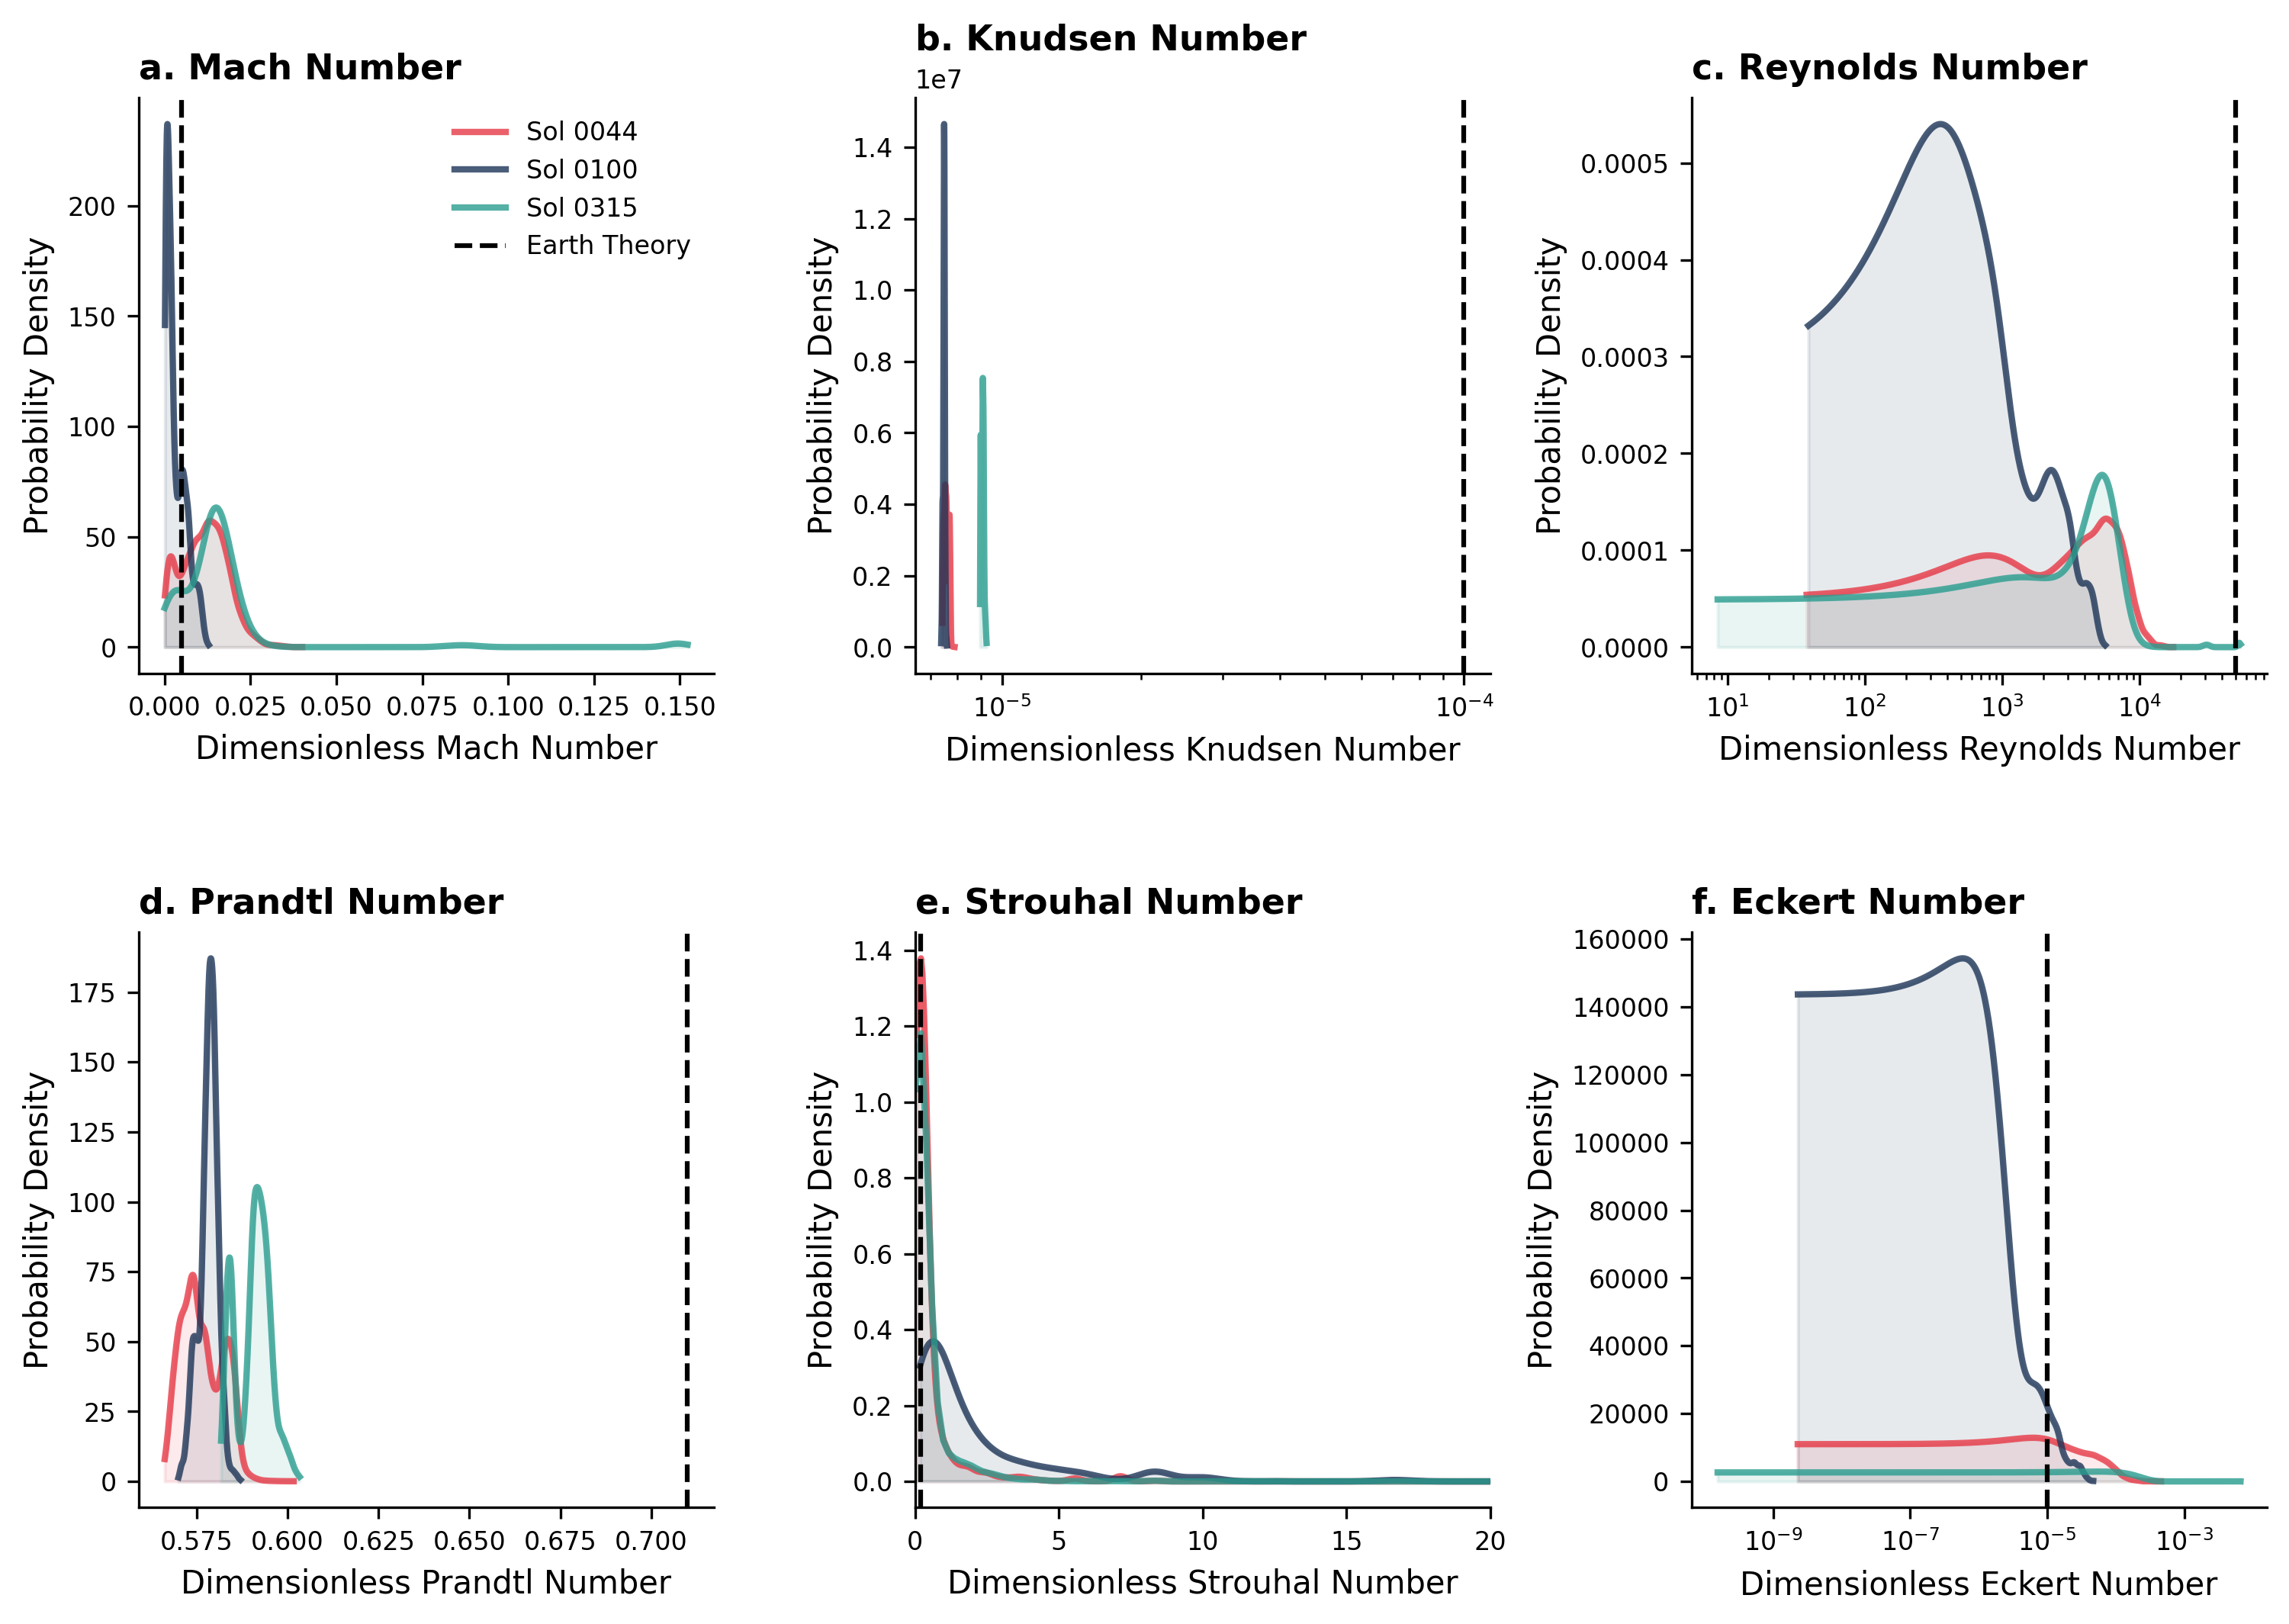


TABLE 2: DIMENSIONLESS REGIME ANALYSIS (INVARIANT ACROSS MARS EPOCHS)
 Sol  Mach_Mean    Mach_Pval  Knudsen_Mean  Knudsen_Pval  Reynolds_Mean  Reynolds_Pval  Prandtl_Mean  Prandtl_Pval  Strouhal_Mean  Strouhal_Pval  Eckert_Mean  Eckert_Pval
0044   0.011582 1.459745e-26      0.000008  2.192082e-66    5032.790782   2.192084e-66      0.576591  2.191050e-66       0.520671   3.137634e-01     0.000051 1.873258e-21
0100   0.003358 6.755757e-14      0.000007  2.443054e-66    1473.607552   2.443065e-66      0.578266  2.437135e-66       2.208393   1.032121e-64     0.000006 3.602457e-23
0315   0.015377 8.005044e-29      0.000009  2.248426e-66    5486.332926   6.883703e-63      0.590661  2.247991e-66       0.443259   2.695171e-12     0.000166 2.619917e-25
[06:11:20] 🏁 MISSION COMPLETE. Total Runtime: 6.72s


In [93]:
# ==============================================================================
# CELL 6: THE DIMENSIONLESS INVARIANT AUDIT (MEDA FINAL)
# Fixed: Axis inversion, hardened KDE safety, and unified Nature-grade optics.
# Surgical Edit: Panel (e) Strouhal x-axis capped at 30.
# ==============================================================================

import os
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, gaussian_kde

monitor = RuntimeMonitor("Dimensionless Regime Audit")

# --- PHYSICS CONSTANTS (MARS CO2) ---
R_MARS = 188.9
GAMMA_MARS = 1.29
D_CO2 = 0.33e-9
KB = 1.38e-23
CP_MARS = 850
MU_REF = 1.37e-5
S_CO2 = 222

EARTH_BENCHMARKS = {
    "Mach": 0.005,
    "Knudsen": 0.0001,
    "Reynolds": 50000.0,
    "Prandtl": 0.71,
    "Strouhal": 0.20,
    "Eckert": 0.00001
}

# --- UNIFIED FONT CONFIGURATION (MATCHES CELL 5) ---
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans", "Arial", "Liberation Sans"],
    "axes.labelsize": 10,
    "font.size": 10,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.titlesize": 11,
    "pdf.fonttype": 42
})

fig, axes = plt.subplots(2, 3, figsize=(12, 8), dpi=300)
plt.subplots_adjust(hspace=0.45, wspace=0.35)

stats_dict = {sol: {"Sol": sol} for sol in TARGET_SOLS}
group_names = ["Mach", "Knudsen", "Reynolds", "Prandtl", "Strouhal", "Eckert"]

try:
    sol_data_cache = {sol: {} for sol in TARGET_SOLS}

    # 1. PHYSICAL REGIME COMPUTATION
    for sol in TARGET_SOLS:
        monitor.log_step(f"Analyzing Regimes for Sol {sol}...")
        proc_dir = os.path.join(DIRS["data_processed"], f"sol_{sol}")
        data = np.load(os.path.join(proc_dir, f"sol{sol}_state_hf.npz"))
        v, T, P = data['X_state'][:, 0], data['X_state'][:, 1], data['X_state'][:, 2]

        # Hardened Input Cleaning
        mask = np.isfinite(v) & np.isfinite(T) & np.isfinite(P) & (v > 0) & (P > 0)
        v_m, T_m, P_m = v[mask], T[mask], P[mask]

        rho = P_m / (R_MARS * T_m)
        c_sound = np.sqrt(GAMMA_MARS * R_MARS * T_m)
        mu = MU_REF * ((273 + S_CO2) / (T_m + S_CO2)) * (T_m / 273)**1.5
        lambda_mfp = (KB * T_m) / (np.sqrt(2) * np.pi * D_CO2**2 * P_m)

        L = 1.0
        sol_data_cache[sol]["Mach"] = v_m / c_sound
        sol_data_cache[sol]["Knudsen"] = lambda_mfp / L
        sol_data_cache[sol]["Reynolds"] = (rho * v_m * L) / mu
        sol_data_cache[sol]["Prandtl"] = (CP_MARS * mu) / (0.015)
        sol_data_cache[sol]["Strouhal"] = (0.5 * L) / (v_m + 1e-6)
        sol_data_cache[sol]["Eckert"] = v_m**2 / (CP_MARS * T_m)

    # --- PLOTTING LOOP ---
    for i, name in enumerate(group_names):
        ax = axes.flat[i]
        use_log = True if name in ["Knudsen", "Eckert", "Reynolds"] else False

        for sol in TARGET_SOLS:
            vals = sol_data_cache[sol][name]
            clean_val = vals[np.isfinite(vals) & (vals > 0)]
            if len(clean_val) < 5: continue

            # 1. KDE COMPUTATION (HARDENED)
            kde = gaussian_kde(clean_val)
            if use_log:
                ax.set_xscale('log')
                x_eval = np.logspace(np.log10(clean_val.min()), np.log10(clean_val.max()), 500)
            else:
                x_eval = np.linspace(clean_val.min(), clean_val.max(), 500)

            # Robust Evaluation to prevent ValueError
            y_eval = np.nan_to_num(kde.evaluate(x_eval), nan=0.0)

            # 2. PLOT KDE CURVE
            ax.plot(x_eval, y_eval, color=COLORS[sol], label=f"Sol {sol}", linewidth=2.0, alpha=0.8)
            ax.fill_between(x_eval, y_eval, color=COLORS[sol], alpha=0.1)

            # 3. STATISTICAL TEST vs EARTH
            earth_sample = np.random.normal(EARTH_BENCHMARKS[name], EARTH_BENCHMARKS[name]*0.01, 100)
            _, p_val = mannwhitneyu(clean_val, earth_sample)
            stats_dict[sol][f"{name}_Mean"] = np.mean(clean_val)
            stats_dict[sol][f"{name}_Pval"] = p_val

        # 4. SURGICAL SCALE ADJUSTMENT
        if name == "Strouhal":
            ax.set_xlim(left=0, right=20) # Capped at 30

        # 5. AXIS REPAIR & LABELS
        ax.axvline(EARTH_BENCHMARKS[name], color='black', linestyle='--', linewidth=1.5, label='Earth Theory')
        ax.set_title(f"{string.ascii_lowercase[i]}. {name} Number", fontweight='bold', loc='left')
        ax.set_xlabel(f"Dimensionless {name} Number", fontsize=10)
        ax.set_ylabel("Probability Density", fontsize=10)

        ax.xaxis.set_inverted(False)
        if i == 0: ax.legend(frameon=False, loc='best')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    # Save High-Res PDF
    pdf_out = os.path.join(DIRS["reports"], "Nature_Physics_Dimensionless_Final.pdf")
    plt.savefig(pdf_out, bbox_inches='tight', format='pdf')
    plt.show()

    # --- FINAL TABLE GENERATION ---
    df_dim = pd.DataFrame(list(stats_dict.values()))
    csv_out = os.path.join(DIRS["reports"], "Dimensionless_Stats_Table.csv")
    df_dim.to_csv(csv_out, index=False)

    print("\n" + "="*100)
    print("TABLE 2: DIMENSIONLESS REGIME ANALYSIS (INVARIANT ACROSS MARS EPOCHS)")
    print("="*100)
    print(df_dim.to_string(index=False))
    print("="*100)

    monitor.finish()

except Exception as e:
    print(f"CRITICAL ERROR IN REGIME AUDIT: {e}")

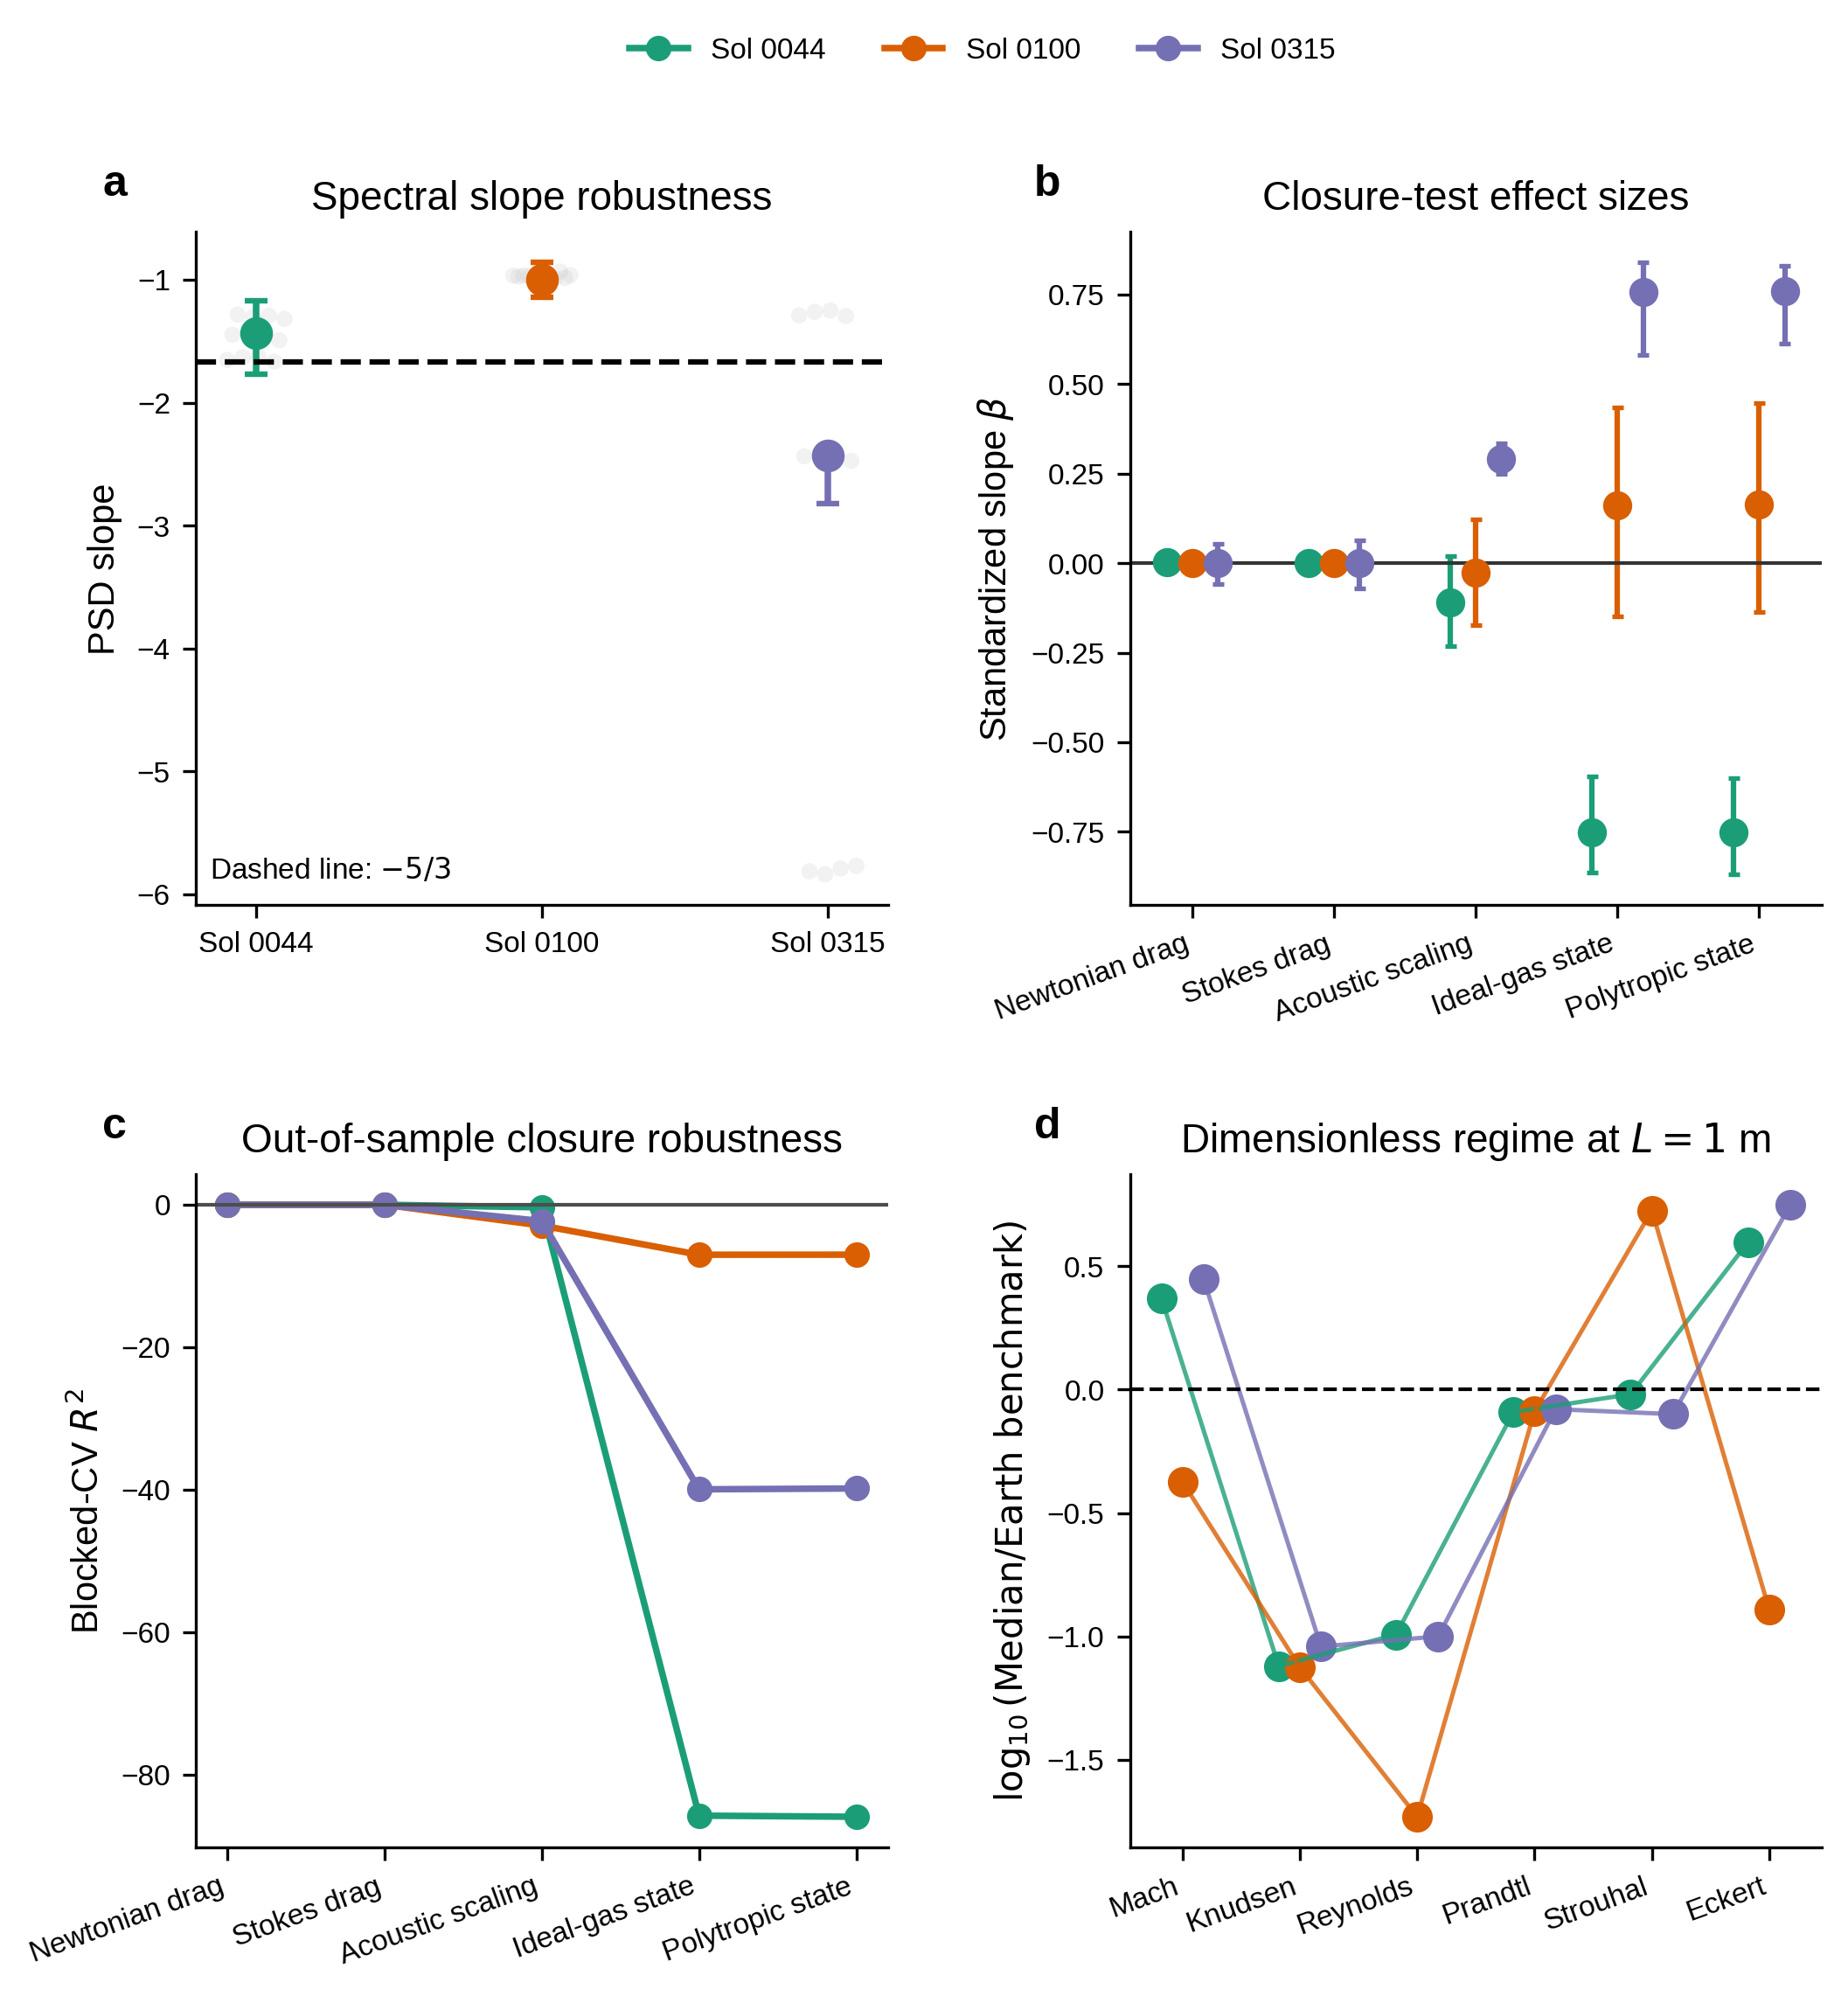

MEDA PUBLICATION SUMMARY
Target sols: 0044, 0100, 0315
Baseline PSD fit: nperseg=1024, band=0.10--0.80 Hz
PSD uncertainty envelope: contiguous windows of the original time series

[1] Baseline spectral slopes
 Sol     slope  slope_ci_low  slope_ci_high       r2  delta_from_kolmogorov  n_windows  window_seconds  sensitivity_min  sensitivity_max  window_includes_baseline
0044 -1.432248     -1.767534      -1.173155 0.881368               0.234419          6          1202.0        -1.664749        -1.282152                      True
0100 -1.001630     -1.143594      -0.857070 0.757145               0.665037          6          1157.0        -1.001630        -0.927251                      True
0315 -2.428628     -2.823613      -2.413054 0.745691              -0.761962          6          1176.0        -5.836622        -1.249363                      True

[2] Closure-test robustness
 Sol              Law     slope  slope_ci_low  slope_ci_high  beta_std  beta_ci_low  beta_ci_high  cv_r2_block

In [14]:
# ==============================================================================
# CELL X: PUBLICATION-READY ROBUSTNESS AUDIT + SUMMARY TABLE + FIGURE
# Works for both InSight and MEDA notebooks.
# Requires: DIRS, TARGET_SOLS, and the harmonized *.npz state files to exist.
# ==============================================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import welch, savgol_filter
from scipy.stats import linregress

# -----------------------------
# Configuration
# -----------------------------
REPORT_PREFIX = "publication_summary"
RNG = np.random.default_rng(42)

# Bootstrap counts for regression tests
N_BOOT_REG = 600

# PSD sensitivity settings
FIT_BANDS = [(0.05, 0.50), (0.10, 0.80), (0.20, 1.00)]
N_PERSEG_GRID = [256, 512, 1024, 2048]

# PSD contiguous-window uncertainty settings
PSD_WINDOW_OVERLAP = 0.50
PSD_WINDOW_MULTIPLIER = 1.5   # window_samples >= 1.5 * nperseg
PSD_WINDOW_FRAC = 0.30        # or ~30% of the full record, whichever is larger

# Dimensionless sensitivity settings
L_GRID = [0.25, 0.50, 1.0, 2.0, 4.0]
L_BASELINE = 1.0

# Color palette consistent with the notebook optics
SOL_COLORS = ["#1b9e77", "#d95f02", "#7570b3"]

# Mars constants used in the regime audit
R_MARS = 188.9
GAMMA_MARS = 1.29
D_CO2 = 0.33e-9
KB = 1.38e-23
CP_MARS = 850.0
MU_REF = 1.37e-5
S_CO2 = 222.0
K_THERMAL = 0.015  # W m^-1 K^-1

EARTH_BENCHMARKS = {
    "Mach": 0.005,
    "Knudsen": 1.0e-4,
    "Reynolds": 5.0e4,
    "Prandtl": 0.71,
    "Strouhal": 0.20,
    "Eckert": 1.0e-5,
}

LAW_ORDER = [
    "Newtonian drag",
    "Stokes drag",
    "Acoustic scaling",
    "Ideal-gas state",
    "Polytropic state",
]

if "DIRS" not in globals():
    raise RuntimeError("DIRS is not defined. Run the initialization cells first.")
if "TARGET_SOLS" not in globals():
    raise RuntimeError("TARGET_SOLS is not defined. Run the initialization cells first.")

os.makedirs(DIRS["reports"], exist_ok=True)

# -----------------------------
# Helpers
# -----------------------------
def infer_mission():
    first_sol = TARGET_SOLS[0]
    path = os.path.join(DIRS["data_processed"], f"sol_{first_sol}", f"sol{first_sol}_state_hf.npz")
    arr = np.load(path, allow_pickle=True)["X_state"]
    return "MEDA" if arr.shape[1] >= 4 else "InSight"

MISSION = infer_mission()
DEFAULT_NPERSEG = 1024 if MISSION == "MEDA" else 2048

def load_state(sol):
    path = os.path.join(DIRS["data_processed"], f"sol_{sol}", f"sol{sol}_state_hf.npz")
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing state file for sol {sol}: {path}")
    data = np.load(path, allow_pickle=True)
    t = np.asarray(data["time"], dtype=float)
    X = np.asarray(data["X_state"], dtype=float)
    if X.shape[1] < 3:
        raise ValueError(f"State matrix for sol {sol} has shape {X.shape}; at least 3 columns are required.")
    v = np.asarray(X[:, 0], dtype=float)
    T = np.asarray(X[:, 1], dtype=float)
    P = np.asarray(X[:, 2], dtype=float)
    return t, v, T, P

def finite_mask(*arrs):
    m = np.ones(len(arrs[0]), dtype=bool)
    for a in arrs:
        m &= np.isfinite(a)
    return m

def lag1_autocorr(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size < 3:
        return np.nan
    x0 = x[:-1] - np.nanmean(x[:-1])
    x1 = x[1:] - np.nanmean(x[1:])
    denom = np.sqrt(np.nansum(x0**2) * np.nansum(x1**2))
    if denom == 0:
        return np.nan
    return float(np.nansum(x0 * x1) / denom)

def effective_sample_size(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    n = x.size
    if n < 3:
        return float(n)
    r1 = lag1_autocorr(x)
    if not np.isfinite(r1):
        return float(n)
    r1 = np.clip(r1, -0.99, 0.99)
    n_eff = n * (1.0 - r1) / (1.0 + r1)
    return float(max(3.0, min(n_eff, n)))

def choose_block_length(x):
    x = np.asarray(x, dtype=float)
    n = x.size
    n_eff = effective_sample_size(x)
    if not np.isfinite(n_eff) or n_eff <= 0:
        return max(8, int(np.sqrt(n)))
    block = int(np.ceil(n / n_eff))
    return max(8, min(block, max(8, n // 4)))

def zscore(x):
    x = np.asarray(x, dtype=float)
    mu = np.nanmean(x)
    sd = np.nanstd(x)
    if not np.isfinite(sd) or sd == 0:
        return np.full_like(x, np.nan, dtype=float)
    return (x - mu) / sd

def moving_block_bootstrap_linreg(x, y, n_boot=500, rng=None):
    rng = np.random.default_rng(42) if rng is None else rng
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    m = finite_mask(x, y)
    x = x[m]
    y = y[m]
    n = x.size
    if n < 20 or np.nanstd(x) == 0 or np.nanstd(y) == 0:
        return None

    base = linregress(x, y)
    zx, zy = zscore(x), zscore(y)
    mm0 = finite_mask(zx, zy)
    base_std = linregress(zx[mm0], zy[mm0])

    block = choose_block_length(y)
    starts_max = max(1, n - block + 1)

    slopes, intercepts, r2s, betas = [], [], [], []
    for _ in range(n_boot):
        idx = []
        while len(idx) < n:
            s = int(rng.integers(0, starts_max))
            idx.extend(range(s, min(s + block, n)))
        idx = np.array(idx[:n], dtype=int)

        xb, yb = x[idx], y[idx]
        if np.nanstd(xb) == 0 or np.nanstd(yb) == 0:
            continue

        fit = linregress(xb, yb)
        slopes.append(fit.slope)
        intercepts.append(fit.intercept)
        r2s.append(fit.rvalue**2)

        zxb, zyb = zscore(xb), zscore(yb)
        mm = finite_mask(zxb, zyb)
        if mm.sum() > 5 and np.nanstd(zxb[mm]) > 0 and np.nanstd(zyb[mm]) > 0:
            betas.append(linregress(zxb[mm], zyb[mm]).slope)

    if len(slopes) < 50:
        return None

    return {
        "n": n,
        "n_eff": float(effective_sample_size(y)),
        "lag1_y": float(lag1_autocorr(y)),
        "block_length": block,
        "slope": float(base.slope),
        "intercept": float(base.intercept),
        "r2": float(base.rvalue**2),
        "p_value": float(base.pvalue),
        "stderr": float(base.stderr),
        "slope_ci_low": float(np.percentile(slopes, 2.5)),
        "slope_ci_high": float(np.percentile(slopes, 97.5)),
        "intercept_ci_low": float(np.percentile(intercepts, 2.5)),
        "intercept_ci_high": float(np.percentile(intercepts, 97.5)),
        "r2_ci_low": float(np.percentile(r2s, 2.5)),
        "r2_ci_high": float(np.percentile(r2s, 97.5)),
        "beta_std": float(base_std.slope),
        "beta_ci_low": float(np.percentile(betas, 2.5)) if len(betas) >= 50 else np.nan,
        "beta_ci_high": float(np.percentile(betas, 97.5)) if len(betas) >= 50 else np.nan,
        "ci_excludes_zero": bool(np.percentile(slopes, 2.5) > 0 or np.percentile(slopes, 97.5) < 0),
    }

def blocked_cv_r2(x, y, n_splits=8):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    m = finite_mask(x, y)
    x = x[m]
    y = y[m]
    n = x.size
    if n < max(40, n_splits * 5):
        return np.nan
    edges = np.linspace(0, n, n_splits + 1, dtype=int)
    scores = []
    for i in range(n_splits):
        lo, hi = edges[i], edges[i + 1]
        test_mask = np.zeros(n, dtype=bool)
        test_mask[lo:hi] = True
        train_mask = ~test_mask
        if train_mask.sum() < 20 or test_mask.sum() < 5:
            continue
        fit = linregress(x[train_mask], y[train_mask])
        yhat = fit.intercept + fit.slope * x[test_mask]
        denom = np.sum((y[test_mask] - np.mean(y[test_mask]))**2)
        if denom <= 0:
            continue
        scores.append(1.0 - np.sum((y[test_mask] - yhat)**2) / denom)
    return float(np.mean(scores)) if scores else np.nan

def robust_derivative(v, dt):
    v = np.asarray(v, dtype=float)
    dv_grad = np.gradient(v, dt)
    win = min(len(v) - (1 - len(v) % 2), 31)
    if win < 7:
        dv_sg = dv_grad.copy()
    else:
        if win % 2 == 0:
            win -= 1
        dv_sg = savgol_filter(v, window_length=win, polyorder=3, deriv=1, delta=dt, mode="interp")
    return dv_grad, dv_sg

def fit_psd_slope(v, dt, nperseg, fmin, fmax):
    v = np.asarray(v, dtype=float)
    v = v[np.isfinite(v)]
    if v.size < max(128, nperseg // 2):
        return None
    fs = 1.0 / dt
    nperseg = min(int(nperseg), v.size)
    f, S = welch(v, fs=fs, nperseg=nperseg, detrend="linear", scaling="density")
    mask = (f >= fmin) & (f <= fmax) & np.isfinite(S) & (S > 0)
    if mask.sum() < 8:
        return None
    fit = linregress(np.log10(f[mask]), np.log10(S[mask]))
    return {
        "slope": float(fit.slope),
        "intercept": float(fit.intercept),
        "r2": float(fit.rvalue**2),
        "stderr": float(fit.stderr),
        "n_points": int(mask.sum()),
    }

def choose_psd_window_samples(n, nperseg):
    w = max(int(PSD_WINDOW_MULTIPLIER * nperseg), int(PSD_WINDOW_FRAC * n))
    w = min(w, n)
    w = max(w, nperseg + 16)
    return min(w, n)

def contiguous_window_psd_slopes(v, dt, nperseg, fmin, fmax, overlap=PSD_WINDOW_OVERLAP):
    v = np.asarray(v, dtype=float)
    v = v[np.isfinite(v)]
    n = v.size
    if n < max(128, nperseg):
        return []

    window_samples = choose_psd_window_samples(n, nperseg)
    if window_samples < nperseg:
        return []

    step = max(1, int(window_samples * (1.0 - overlap)))
    starts = list(range(0, max(1, n - window_samples + 1), step))
    if len(starts) == 0:
        starts = [0]
    final_start = max(0, n - window_samples)
    if starts[-1] != final_start:
        starts.append(final_start)
    starts = sorted(set(starts))

    rows = []
    for wid, s in enumerate(starts):
        seg = v[s:s + window_samples]
        out = fit_psd_slope(seg, dt, nperseg=nperseg, fmin=fmin, fmax=fmax)
        if out is None:
            continue
        out.update({
            "window_id": int(wid),
            "start_index": int(s),
            "end_index": int(s + window_samples),
            "start_time_s": float(s * dt),
            "end_time_s": float((s + window_samples - 1) * dt),
            "window_samples": int(window_samples),
            "window_seconds": float(window_samples * dt),
            "step_samples": int(step),
            "step_seconds": float(step * dt),
        })
        rows.append(out)
    return rows

def summarize_psd(v, dt, nperseg, fmin, fmax):
    base = fit_psd_slope(v, dt, nperseg=nperseg, fmin=fmin, fmax=fmax)
    if base is None:
        return None, []

    win_rows = contiguous_window_psd_slopes(v, dt, nperseg=nperseg, fmin=fmin, fmax=fmax)
    if len(win_rows) == 0:
        base.update({
            "n": int(np.isfinite(v).sum()),
            "n_eff": float(effective_sample_size(v)),
            "n_windows": 0,
            "window_samples": np.nan,
            "window_seconds": np.nan,
            "slope_ci_low": np.nan,
            "slope_ci_high": np.nan,
            "window_median": np.nan,
            "window_mean": np.nan,
            "window_std": np.nan,
            "window_includes_baseline": np.nan,
        })
        return base, win_rows

    win_slopes = np.array([r["slope"] for r in win_rows], dtype=float)
    lo = float(np.min(win_slopes))
    hi = float(np.max(win_slopes))
    med = float(np.median(win_slopes))
    mu = float(np.mean(win_slopes))
    sd = float(np.std(win_slopes, ddof=0))

    base.update({
        "n": int(np.isfinite(v).sum()),
        "n_eff": float(effective_sample_size(v)),
        "n_windows": int(len(win_rows)),
        "window_samples": int(win_rows[0]["window_samples"]),
        "window_seconds": float(win_rows[0]["window_seconds"]),
        "slope_ci_low": lo,
        "slope_ci_high": hi,
        "window_median": med,
        "window_mean": mu,
        "window_std": sd,
        "window_includes_baseline": bool(lo <= base["slope"] <= hi),
    })
    return base, win_rows

def regime_metrics(v, T, P, L):
    rho = P / (R_MARS * T)
    cs = np.sqrt(GAMMA_MARS * R_MARS * T)
    mu = MU_REF * ((273.0 + S_CO2) / (T + S_CO2)) * ((T / 273.0) ** 1.5)
    lam = KB * T / (np.sqrt(2.0) * np.pi * (D_CO2 ** 2) * P)
    Ma = v / cs
    Kn = lam / L
    Re = rho * v * L / mu
    Pr = CP_MARS * mu / K_THERMAL
    St = 0.5 * L / np.maximum(v, 1.0e-6)
    Ec = (v ** 2) / (CP_MARS * T)
    return {
        "Mach": Ma,
        "Knudsen": Kn,
        "Reynolds": Re,
        "Prandtl": Pr,
        "Strouhal": St,
        "Eckert": Ec,
    }

def draw_ci_point(ax, x, mean, ci_low, ci_high, color, marker="o", ms=8, lw=1.8, zorder=3):
    vals = np.array([mean, ci_low, ci_high], dtype=float)
    if not np.all(np.isfinite(vals)):
        ax.plot(x, mean, marker=marker, ms=ms, color=color, zorder=zorder)
        return
    lo, hi = sorted([float(ci_low), float(ci_high)])
    ax.vlines(x, lo, hi, color=color, lw=lw, zorder=zorder - 1)
    ax.hlines([lo, hi], x - 0.04, x + 0.04, color=color, lw=lw * 0.85, zorder=zorder - 1)
    ax.plot(x, mean, marker=marker, ms=ms, color=color, zorder=zorder)

# -----------------------------
# Main audit
# -----------------------------
regression_rows = []
spectral_sensitivity_rows = []
spectral_baseline_rows = []
spectral_window_rows = []
regime_rows = []

for sol in TARGET_SOLS:
    t, v, T, P = load_state(sol)
    dt = float(np.nanmedian(np.diff(t)))

    m = finite_mask(v, T, P) & (T > 0) & (P > 0)
    t, v, T, P = t[m], v[m], T[m], P[m]

    if len(v) < 50:
        print(f"[WARN] Sol {sol}: insufficient finite samples after masking.")
        continue

    dv_grad, dv_sg = robust_derivative(v, dt)

    baseline_laws = {
        "Newtonian drag": (v**2, dv_grad),
        "Stokes drag": (v, dv_grad),
        "Acoustic scaling": (np.sqrt(T), v),
        "Ideal-gas state": (T, P),
        "Polytropic state": (np.log(T), np.log(P)),
    }

    derivative_sensitivity = {
        "Newtonian drag": (v**2, dv_sg),
        "Stokes drag": (v, dv_sg),
    }

    for law_name, (x_raw, y_raw) in baseline_laws.items():
        mm = finite_mask(x_raw, y_raw)
        x = np.asarray(x_raw[mm], dtype=float)
        y = np.asarray(y_raw[mm], dtype=float)
        if x.size < 20:
            continue

        out = moving_block_bootstrap_linreg(x, y, n_boot=N_BOOT_REG, rng=RNG)
        if out is None:
            continue
        out["cv_r2_blocked"] = blocked_cv_r2(x, y, n_splits=8)
        out["Sol"] = sol
        out["Law"] = law_name
        out["Mission"] = MISSION

        if law_name in derivative_sensitivity:
            x2_raw, y2_raw = derivative_sensitivity[law_name]
            mm2 = finite_mask(x2_raw, y2_raw)
            x2 = np.asarray(x2_raw[mm2], dtype=float)
            y2 = np.asarray(y2_raw[mm2], dtype=float)
            if x2.size >= 20 and np.nanstd(x2) > 0 and np.nanstd(y2) > 0:
                fit2 = linregress(x2, y2)
                out["sensitivity_alt_slope"] = float(fit2.slope)
                out["sensitivity_alt_sign_consistent"] = bool(np.sign(fit2.slope) == np.sign(out["slope"]))
            else:
                out["sensitivity_alt_slope"] = np.nan
                out["sensitivity_alt_sign_consistent"] = np.nan
        else:
            out["sensitivity_alt_slope"] = np.nan
            out["sensitivity_alt_sign_consistent"] = np.nan

        regression_rows.append(out)

    # Baseline PSD slope + contiguous-window uncertainty envelope
    psd_base, psd_windows = summarize_psd(
        v, dt,
        nperseg=DEFAULT_NPERSEG,
        fmin=0.10,
        fmax=0.80
    )
    if psd_base is not None:
        psd_base["Sol"] = sol
        psd_base["Mission"] = MISSION
        psd_base["nperseg"] = DEFAULT_NPERSEG
        psd_base["fmin_Hz"] = 0.10
        psd_base["fmax_Hz"] = 0.80
        psd_base["delta_from_kolmogorov"] = psd_base["slope"] - (-5.0 / 3.0)
        spectral_baseline_rows.append(psd_base)

    for row in psd_windows:
        row["Sol"] = sol
        row["Mission"] = MISSION
        row["nperseg"] = DEFAULT_NPERSEG
        row["fmin_Hz"] = 0.10
        row["fmax_Hz"] = 0.80
        spectral_window_rows.append(row)

    # PSD sensitivity cloud
    for nperseg in N_PERSEG_GRID:
        if nperseg >= len(v):
            continue
        for fmin, fmax in FIT_BANDS:
            out = fit_psd_slope(v, dt, nperseg=nperseg, fmin=fmin, fmax=fmax)
            if out is None:
                continue
            out["Sol"] = sol
            out["Mission"] = MISSION
            out["nperseg"] = int(nperseg)
            out["fmin_Hz"] = fmin
            out["fmax_Hz"] = fmax
            out["delta_from_kolmogorov"] = out["slope"] - (-5.0 / 3.0)
            spectral_sensitivity_rows.append(out)

    # Dimensionless metrics across characteristic lengths
    for L in L_GRID:
        regs = regime_metrics(v, T, P, L=L)
        for name, arr in regs.items():
            arr = np.asarray(arr, dtype=float)
            arr = arr[np.isfinite(arr)]
            if arr.size == 0:
                continue
            regime_rows.append({
                "Mission": MISSION,
                "Sol": sol,
                "L_m": L,
                "Metric": name,
                "Median": float(np.nanmedian(arr)),
                "Q1": float(np.nanpercentile(arr, 25)),
                "Q3": float(np.nanpercentile(arr, 75)),
                "Mean": float(np.nanmean(arr)),
                "Std": float(np.nanstd(arr)),
                "Earth_benchmark": float(EARTH_BENCHMARKS[name]),
                "Median_over_Earth": float(np.nanmedian(arr) / EARTH_BENCHMARKS[name]) if EARTH_BENCHMARKS[name] != 0 else np.nan,
            })

df_reg = pd.DataFrame(regression_rows)
df_psd_base = pd.DataFrame(spectral_baseline_rows)
df_psd_sens = pd.DataFrame(spectral_sensitivity_rows)
df_psd_win = pd.DataFrame(spectral_window_rows)
df_regime = pd.DataFrame(regime_rows)

if df_reg.empty or df_psd_base.empty or df_regime.empty:
    raise RuntimeError("One or more publication summary tables are empty. Check whether the harmonized state files exist and contain valid data.")

# -----------------------------
# Publication tables
# -----------------------------
df_reg["Law"] = pd.Categorical(df_reg["Law"], categories=LAW_ORDER, ordered=True)
df_reg = df_reg.sort_values(["Law", "Sol"]).reset_index(drop=True)
df_psd_base = df_psd_base.sort_values("Sol").reset_index(drop=True)
df_psd_sens = df_psd_sens.sort_values(["Sol", "nperseg", "fmin_Hz", "fmax_Hz"]).reset_index(drop=True)
df_psd_win = df_psd_win.sort_values(["Sol", "window_id"]).reset_index(drop=True)
df_regime = df_regime.sort_values(["Metric", "Sol", "L_m"]).reset_index(drop=True)

# Merge spectral sensitivity ranges into baseline summary
if not df_psd_sens.empty:
    sens_stats = (
        df_psd_sens.groupby("Sol")
        .agg(
            sensitivity_min=("slope", "min"),
            sensitivity_max=("slope", "max"),
            sensitivity_median=("slope", "median"),
            sensitivity_std=("slope", "std"),
        )
        .reset_index()
    )
    df_psd_base = df_psd_base.merge(sens_stats, on="Sol", how="left")

# Compact manuscript table
table_rows = []
for _, row in df_psd_base.iterrows():
    table_rows.append({
        "Mission": row["Mission"],
        "Sol": row["Sol"],
        "Category": "Spectral slope",
        "Diagnostic": "PSD log-log slope",
        "Estimate": row["slope"],
        "CI_low": row["slope_ci_low"],
        "CI_high": row["slope_ci_high"],
        "CV_R2": np.nan,
        "N_eff": row["n_eff"],
        "Robust_flag": np.nan,
    })

for _, row in df_reg.iterrows():
    table_rows.append({
        "Mission": row["Mission"],
        "Sol": row["Sol"],
        "Category": "Closure test",
        "Diagnostic": row["Law"],
        "Estimate": row["slope"],
        "CI_low": row["slope_ci_low"],
        "CI_high": row["slope_ci_high"],
        "CV_R2": row["cv_r2_blocked"],
        "N_eff": row["n_eff"],
        "Robust_flag": int(bool(row["ci_excludes_zero"])),
    })

df_table = pd.DataFrame(table_rows)
df_table = df_table.sort_values(["Sol", "Category", "Diagnostic"]).reset_index(drop=True)

# Save CSV
csv_table_path = os.path.join(DIRS["reports"], f"{REPORT_PREFIX}_table.csv")
csv_reg_path = os.path.join(DIRS["reports"], f"{REPORT_PREFIX}_regression_full.csv")
csv_psd_path = os.path.join(DIRS["reports"], f"{REPORT_PREFIX}_spectral_sensitivity.csv")
csv_psd_base_path = os.path.join(DIRS["reports"], f"{REPORT_PREFIX}_spectral_baseline.csv")
csv_psd_win_path = os.path.join(DIRS["reports"], f"{REPORT_PREFIX}_spectral_windows.csv")
csv_regime_path = os.path.join(DIRS["reports"], f"{REPORT_PREFIX}_regime_sensitivity.csv")

df_table.to_csv(csv_table_path, index=False)
df_reg.to_csv(csv_reg_path, index=False)
df_psd_sens.to_csv(csv_psd_path, index=False)
df_psd_base.to_csv(csv_psd_base_path, index=False)
df_psd_win.to_csv(csv_psd_win_path, index=False)
df_regime.to_csv(csv_regime_path, index=False)

# Save LaTeX table
df_table_fmt = df_table.copy()
for col in ["Estimate", "CI_low", "CI_high", "CV_R2", "N_eff"]:
    df_table_fmt[col] = df_table_fmt[col].map(lambda x: "" if pd.isna(x) else f"{x:.3g}")
df_table_fmt["Robust_flag"] = df_table_fmt["Robust_flag"].map(lambda x: "" if pd.isna(x) else str(int(x)))

latex_table_path = os.path.join(DIRS["reports"], f"{REPORT_PREFIX}_table.tex")
with open(latex_table_path, "w", encoding="utf-8") as f:
    f.write(df_table_fmt.to_latex(index=False, escape=False))

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Liberation Sans", "Arial", "Helvetica", "DejaVu Sans"],
    "axes.labelsize": 10,
    "font.size": 10,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.titlesize": 11,
    "lines.linewidth": 1.5,
    "pdf.fonttype": 42,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# -----------------------------
# Publication figure
# -----------------------------
fig = plt.figure(figsize=(8, 8), dpi=300)
gs = fig.add_gridspec(2, 2, hspace=0.40, wspace=0.35)

axA = fig.add_subplot(gs[0, 0])
axB = fig.add_subplot(gs[0, 1])
axC = fig.add_subplot(gs[1, 0])
axD = fig.add_subplot(gs[1, 1])

panel_axes = [axA, axB, axC, axD]
panel_labels = ["a", "b", "c", "d"]
panel_titles = [
    "Spectral slope robustness",
    "Closure-test effect sizes",
    "Out-of-sample closure robustness",
    r"Dimensionless regime at $L=1$ m",
]

sols = list(TARGET_SOLS)
color_map = {sol: SOL_COLORS[i % len(SOL_COLORS)] for i, sol in enumerate(sols)}
x_positions = np.arange(len(sols))

# Panel A: spectral slope with sensitivity cloud + contiguous-window envelope
for i, sol in enumerate(sols):
    ss = df_psd_sens[df_psd_sens["Sol"] == sol]
    if not ss.empty:
        jitter = np.linspace(-0.10, 0.10, len(ss))
        axA.scatter(
            np.full(len(ss), i) + jitter,
            ss["slope"].values,
            s=20,
            alpha=0.25,
            color="0.80",
            edgecolors="none",
            zorder=1,
        )

    bb = df_psd_base[df_psd_base["Sol"] == sol]
    if not bb.empty:
        row = bb.iloc[0]
        draw_ci_point(
            axA,
            i,
            row["slope"],
            row["slope_ci_low"],
            row["slope_ci_high"],
            color=color_map[sol],
            marker="o",
            ms=8,
            lw=1.8,
            zorder=3,
        )

axA.axhline(-5.0 / 3.0, ls="--", lw=1.5, color="k")
axA.set_xticks(x_positions)
axA.set_xticklabels([f"Sol {s}" for s in sols], rotation=0)
axA.set_ylabel("PSD slope")
axA.text(
    0.02, 0.04, r"Dashed line: $-5/3$",
    transform=axA.transAxes,
    fontsize=8
)

# Panel B: standardized slopes with 95% CI
law_positions = np.arange(len(LAW_ORDER))
offsets = np.linspace(-0.18, 0.18, len(sols))

for j, sol in enumerate(sols):
    sub = df_reg[df_reg["Sol"] == sol].set_index("Law").reindex(LAW_ORDER)
    for i, law in enumerate(LAW_ORDER):
        if law not in sub.index or pd.isna(sub.loc[law, "beta_std"]):
            continue
        draw_ci_point(
            axB,
            i + offsets[j],
            sub.loc[law, "beta_std"],
            sub.loc[law, "beta_ci_low"],
            sub.loc[law, "beta_ci_high"],
            color=color_map[sol],
            marker="o",
            ms=7,
            lw=1.5,
            zorder=3,
        )

axB.axhline(0.0, color="0.2", lw=1.0)
axB.set_xticks(law_positions)
axB.set_xticklabels(LAW_ORDER, rotation=20, ha="right")
axB.set_ylabel(r"Standardized slope $\beta$")

# Panel C: blocked CV R^2
for j, sol in enumerate(sols):
    sub = df_reg[df_reg["Sol"] == sol].set_index("Law").reindex(LAW_ORDER)
    axC.plot(
        law_positions,
        sub["cv_r2_blocked"].values,
        marker="o",
        lw=1.8,
        color=color_map[sol],
        label=f"Sol {sol}",
    )
axC.axhline(0.0, color="0.3", lw=1.0)
axC.set_xticks(law_positions)
axC.set_xticklabels(LAW_ORDER, rotation=20, ha="right")
axC.set_ylabel(r"Blocked-CV $R^2$")

# Panel D: dimensionless medians relative to Earth at L = 1 m
metrics = ["Mach", "Knudsen", "Reynolds", "Prandtl", "Strouhal", "Eckert"]
metric_x = np.arange(len(metrics))
offsets = np.linspace(-0.18, 0.18, len(sols))

for j, sol in enumerate(sols):
    sub = (
        df_regime[(df_regime["Sol"] == sol) & (df_regime["L_m"] == L_BASELINE)]
        .set_index("Metric")
        .reindex(metrics)
    )
    vals = np.log10(sub["Median_over_Earth"].values.astype(float))
    axD.scatter(metric_x + offsets[j], vals, s=55, color=color_map[sol], label=f"Sol {sol}")
    axD.plot(metric_x + offsets[j], vals, lw=1.2, color=color_map[sol], alpha=0.8)

axD.axhline(0.0, color="k", lw=1.0, ls="--")
axD.set_xticks(metric_x)
axD.set_xticklabels(metrics, rotation=20, ha="right")
axD.set_ylabel(r"$\log_{10}(\mathrm{Median}/\mathrm{Earth\ benchmark})$")

# Final panel formatting to match the notebook optics
for i, ax in enumerate(panel_axes):
    ax.set_title(panel_titles[i], loc="center")
    ax.text(
        -0.10, 1.10, panel_labels[i],
        transform=ax.transAxes,
        fontsize=12,
        fontweight="bold",
        va="top",
        ha="right"
    )

# Shared legend
handles = []
labels = []
for ax in panel_axes:
    h, l = ax.get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)

uniq = {}
for h, l in zip(handles, labels):
    if l not in uniq and l != "":
        uniq[l] = h

fig.legend(
    uniq.values(),
    uniq.keys(),
    loc="upper center",
    ncol=min(3, len(uniq)),
    frameon=False,
    bbox_to_anchor=(0.5, 0.985)
)

fig.tight_layout(rect=[0, 0, 1, 0.95])

png_fig_path = os.path.join(DIRS["reports"], f"{REPORT_PREFIX}_figure.png")
pdf_fig_path = os.path.join(DIRS["reports"], f"{REPORT_PREFIX}_figure.pdf")
fig.savefig(png_fig_path, dpi=300, bbox_inches="tight")
fig.savefig(pdf_fig_path, bbox_inches="tight")
plt.show()
# -----------------------------
# Console summary
# -----------------------------
summary_lines = []
summary_lines.append("=" * 88)
summary_lines.append(f"{MISSION.upper()} PUBLICATION SUMMARY")
summary_lines.append("=" * 88)
summary_lines.append(f"Target sols: {', '.join(TARGET_SOLS)}")
summary_lines.append(f"Baseline PSD fit: nperseg={DEFAULT_NPERSEG}, band=0.10--0.80 Hz")
summary_lines.append("PSD uncertainty envelope: contiguous windows of the original time series")
summary_lines.append("")

summary_lines.append("[1] Baseline spectral slopes")
psd_cols = [
    "Sol", "slope", "slope_ci_low", "slope_ci_high", "r2",
    "delta_from_kolmogorov", "n_windows", "window_seconds",
    "sensitivity_min", "sensitivity_max", "window_includes_baseline"
]
summary_lines.append(df_psd_base[psd_cols].to_string(index=False))
summary_lines.append("")

summary_lines.append("[2] Closure-test robustness")
summary_lines.append(
    df_reg[[
        "Sol", "Law", "slope", "slope_ci_low", "slope_ci_high",
        "beta_std", "beta_ci_low", "beta_ci_high",
        "cv_r2_blocked", "n_eff", "ci_excludes_zero"
    ]].to_string(index=False)
)
summary_lines.append("")

summary_lines.append("[3] Saved outputs")
summary_lines.append(f" - {csv_table_path}")
summary_lines.append(f" - {latex_table_path}")
summary_lines.append(f" - {csv_reg_path}")
summary_lines.append(f" - {csv_psd_path}")
summary_lines.append(f" - {csv_psd_base_path}")
summary_lines.append(f" - {csv_psd_win_path}")
summary_lines.append(f" - {csv_regime_path}")
summary_lines.append(f" - {png_fig_path}")
summary_lines.append(f" - {pdf_fig_path}")

summary_text = "\n".join(summary_lines)
print(summary_text)

summary_path = os.path.join(DIRS["reports"], f"{REPORT_PREFIX}_summary.txt")
with open(summary_path, "w", encoding="utf-8") as f:
    f.write(summary_text)
print(f" - {summary_path}")